# Bitcoin: predicting tomorrow's 24 hourly price changes
### Version 3: why the hourly forecasts look like noise, and how to get real results

Versions 1 and 2 (`bitcoin-models-new-data.ipynb`, `bitcoin-models-2018-2026.ipynb`) showed that no model beats the "predict 0%" forecast for the 24 hourly returns. This notebook asks **why**, and implements a list of improvements, first **one at a time** and then **all together**, so the effect of each one can be measured.

It keeps the setup of version 2: only 2018–2026 data, three calendar blocks (train 2018 → 2022, validation 2023 → Jun 2024, test Jul 2024 → Oct 2026), hyperparameters are never chosen on the test block.

| # | Improvement | Section |
|---|---|---|
| A1 | "Is there anything to predict?": autocorrelation, statistical tests, intraday patterns | 4 |
| A6 + A2 | One model for all 24 hours ("long format"), and a new hourly target: the **size** of each hourly move | 5 |
| A3 | Hourly **prediction ranges** (quantile regression) instead of single numbers | 6 |
| A4 | Fixing the metric mismatch: choosing models by R²/IC, Diebold–Mariano test, confident forecasts | 7 |
| B1–B4 | Better features: 30-day history, volatility from High/Low, calendar profiles, feature selection | 8 |
| C1 + C2 | Walk-forward validation inside train + validation, time-aware early stopping | 9 |
| A5 + C3 | Volatility-scaled return target, robust loss and sample weights | 10 |
| C4–C6 | More scikit-learn models, ensembles, smarter hyperparameter search | 11 |
| — | **All improvements together** vs. each one separately, on the test block | 12 |
| D3 | Economic evaluation: what are the forecasts worth in a simple strategy? | 13 |
| D1, D2, D4 | Confidence intervals, learning curves, regimes and calibration | 14 |
| D5 | Shared code in `btc_utils.py`, `requirements.txt` | (files) |
| — | Conclusions, and ideas for further work | 15, 16 |

Sections 1–3 prepare the data, the features and the blocks.

All models are standard scikit-learn models: we only choose their inputs, targets and hyperparameters.

## 1. Load the data as one continuous hourly series

The data-preparation step stores 129,195 overlapping windows of 168 hours (each hour appears in up to 168 windows). For this version we turn them back into **one continuous hourly series** (Open, High, Low, Close, Volume, Return), using the scaler to undo the standardization. Nothing in the data files changes: this is a model-side re-arrangement, and the next cell verifies that it is exact.

**Why?** Many improvements below need information the 168-hour window cannot hold: the volatility of the last 30 days (B1), the same hour yesterday and last week for each predicted hour (B3), or a series to compute autocorrelations on (A1). With the continuous series every feature becomes a simple rolling statistic.

The helper functions live in `btc_utils.py` (improvement D5): data loading, features, targets, metrics and statistical tests. Each function has a docstring explaining what it does.

**Forecast origin.** For every window, the *origin* is its last input hour: the moment the forecast is made. The model sees only hours up to the origin and predicts the 24 hours after it.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression, ElasticNet, HuberRegressor, QuantileRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor,
                              HistGradientBoostingClassifier)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import ParameterGrid, ParameterSampler, TimeSeriesSplit
from sklearn.experimental import enable_halving_search_cv  # noqa: F401  (needed to import HalvingGridSearchCV)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import mean_absolute_error, roc_auc_score, accuracy_score, balanced_accuracy_score, log_loss
from sklearn.exceptions import ConvergenceWarning
from scipy import stats

import btc_utils as U

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*Trying to unpickle.*")
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
RANDOM_STATE = 42
T_START = time.time()

hourly, origins, y_all, X_windows, scaler = U.load_hourly()
print(f"Hourly series: {len(hourly):,} hours, {hourly.index[0]} -> {hourly.index[-1]}")
print(f"Windows: {len(origins):,}, origins {origins[0]} -> {origins[-1]}")

Hourly series: 129,362 hours, 2012-01-01 01:00:00 -> 2026-10-04 02:00:00
Windows: 129,195, origins 2012-01-08 00:00:00 -> 2026-10-04 02:00:00


In [2]:
# Verification: the series reproduces every window and every target exactly
pos_all = hourly.index.get_indexer(origins)                 # position of each origin in the series
rng = np.random.default_rng(0)
check = rng.integers(0, len(origins), 500)
unscaled = lambda w: np.c_[w[:, :5] * scaler.scale_[:5] + scaler.mean_[:5], (w[:, 5] * scaler.scale_[5] + scaler.mean_[5]) * 100]
same_windows = all(np.allclose(unscaled(X_windows[i].astype(float)), hourly.values[pos_all[i] - 167: pos_all[i] + 1],
                               rtol=1e-6, atol=1e-6) for i in check)
future = np.stack([hourly["Return"].values[pos_all[:-24] + k] for k in range(1, 25)], axis=1)
print("Series has no missing hours:", (np.diff(hourly.index.values) == np.timedelta64(1, "h")).all())
print("500 random windows equal the matching slice of the series:", same_windows)
print("Targets y equal the next 24 returns of the series:", np.allclose(y_all[:-24], future, atol=1e-6))
del X_windows                                               # 500 MB that are no longer needed

Series has no missing hours: True
500 random windows equal the matching slice of the series: True
Targets y equal the next 24 returns of the series: True


## 2. Features

Three groups are computed at every hour of the series. Section 8 measures what each group adds.

| Group | Features | Idea |
|---|---|---|
| **Base** (versions 1–2) | 42 features: last 24 returns, mean/std of returns over 24/72/168 h, 24 h and 7-day return, position in the week's range, distance to the week mean, High–Low range, volume vs. week, hour and weekday of the first predicted hour | unchanged, so results stay comparable |
| **B1: 30-day history** | log realized volatility of the last day, week and month (the *HAR* model of volatility research), week vs. month volatility, 30-day return, distance to the 30-day mean, 30-day std of returns | volatility has a long memory; one week of history is not enough to see it |
| **B2: range-based volatility** | Parkinson and Garman–Klass volatility over 24 h, 1 week and 30 days | they use High, Low, Open and Close of every hour, which measures volatility more precisely than squared returns |

A fourth group, **B3: per-hour features**, only exists in the long format of section 5 because it depends on which of the 24 hours is predicted.

The cell below also checks that the base features equal those of versions 1–2.

In [3]:
F_base = U.base_features(hourly)
F_b1 = U.long_lookback_features(hourly)
F_b2 = U.range_vol_features(hourly)
FEAT = pd.concat([F_base, F_b1, F_b2], axis=1)
BASE, B1, B2 = list(F_base.columns), list(F_b1.columns), list(F_b2.columns)
print(f"Base: {len(BASE)} features   B1: {len(B1)}   B2: {len(B2)}")

# Same values as make_features() of version 2? (recomputed here for 300 windows from the series slices)
def v2_features(i):
    w = hourly.iloc[pos_all[i] - 167: pos_all[i] + 1]
    r, c = w["Return"].values, w["Close"].values
    vol = np.log1p(np.maximum(w["Volume"].values, 0))
    return [r[-1 - 0], r[-24:].std(), (c[-1] / c[0] - 1) * 100, vol[-24:].mean() - vol.mean()]
chk = check[:300]
ours = FEAT.iloc[pos_all[chk]][["ret_lag1", "ret_std_24h", "ret_7d", "volume_24h_vs_week"]].values
print("Base features equal the version-2 definition:", np.allclose(ours, [v2_features(i) for i in chk]))

Base: 42 features   B1: 7   B2: 6
Base features equal the version-2 definition: True


## 3. The three blocks

As in version 2: train (2018 → 2022), validation (Jan 2023 → Jun 2024), test (Jul 2024 → Oct 2026), split by the date of the predicted day, with a 192-hour purge before each border so that **no target hour belongs to two blocks**.

One change: the longest feature now looks back 30 days, so the first usable origin is **30 Jan 2018** (all 720 lookback hours inside 2018, in the spirit of "only 2018–2026"). The features of validation and test origins may look back into the previous block: that is not leakage, because those hours are in the past at the moment of the forecast.

Training and validation keep every 6th origin (`STRIDE = 6`, as before); the test block uses every origin. For the single-value daily targets (sections 9–13), the test uses one origin per day (every 24th) so that the days are independent.

In [4]:
DATA_START, VAL_START, TEST_START = pd.Timestamp("2018-01-01"), pd.Timestamp("2023-01-01"), pd.Timestamp("2024-07-01")
STRIDE, WINDOW = 6, pd.Timedelta(hours=192)
day_end = origins + pd.Timedelta(hours=24)                         # last predicted hour (= "dates" of the npz)
usable = origins - pd.Timedelta(hours=U.MONTH - 1) >= DATA_START
blk = {
    "train": np.flatnonzero(usable & (day_end < VAL_START - WINDOW))[::STRIDE],
    "val": np.flatnonzero((day_end >= VAL_START) & (day_end < TEST_START - WINDOW))[::STRIDE],
    "test": np.flatnonzero(day_end >= TEST_START),
}
P = {k: pos_all[v] for k, v in blk.items()}                         # positions in the hourly series
Y = {k: y_all[v] for k, v in blk.items()}                           # next 24 returns, %
D = {k: origins[v] for k, v in blk.items()}                         # origin timestamps
test_days = np.arange(0, len(P["test"]), 24)                        # one origin per day -> independent days
for k in blk:
    print(f"{k:<5} {len(P[k]):>6} origins  {D[k][0]} -> {D[k][-1]}   avg |hourly move| {np.abs(Y[k]).mean():.3f}%")
print(f"independent test days: {len(test_days)}")

def Xw(block, cols):
    """Wide format: one row per origin."""
    return FEAT[cols].values[P[block]]

train   7149 origins  2018-01-30 23:00:00 -> 2022-12-22 23:00:00   avg |hourly move| 0.485%
val     2156 origins  2022-12-31 00:00:00 -> 2024-06-21 18:00:00   avg |hourly move| 0.301%
test   19827 origins  2024-06-30 00:00:00 -> 2026-10-04 02:00:00   avg |hourly move| 0.320%
independent test days: 827


### Shared helpers for tuning and for collecting results

- `tune()` trains every setting of a grid on the train block and scores it on the validation block (as in version 2), printing progress. The `score` column is the metric used to choose; the table is sorted by it.
- `RESULTS` collects every test-block evaluation of the notebook, so section 12 can compare all variants in one table.

In [5]:
RESULTS = []

def record(section, target, variant, **metrics):
    RESULTS.append({"section": section, "target": target, "variant": variant, **metrics})

def tune(make_model, grid, Xtr, ytr, Xva, yva, score_fn, label="", fit_kw=None, show=True):
    """Fit each setting on (Xtr, ytr), score on (Xva, yva). score_fn(y, pred) -> dict with key 'score'."""
    rows, grid = [], list(ParameterGrid(grid))
    for n, p in enumerate(grid, 1):
        t0 = time.time()
        m = make_model(**p).fit(Xtr, ytr, **(fit_kw or {}))
        s = score_fn(yva, m.predict(Xva))
        rows.append({**p, **s, "seconds": round(time.time() - t0, 1)})
        print(f"  {label} [{n}/{len(grid)}] {p} score={s['score']:+.4f}", end="\r", flush=True)
    print()
    t = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    if show:
        display(t.round(4))
    best = {k: (v.item() if isinstance(v, np.generic) else v) for k, v in t.iloc[0][list(grid[0])].items()}
    best = {k: (int(v) if isinstance(v, float) and v.is_integer() and k not in ("learning_rate", "alpha", "max_features", "C", "l1_ratio", "epsilon") else v)
            for k, v in best.items()}
    return t, best

## 4. A1 — Is there anything to predict?

Before training more models, we check the hourly series itself, **on the train block only** (Feb 2018 → Dec 2022, ≈43,000 hours).

**Autocorrelation** (ACF) at lag *k* is the correlation between the value of an hour and the value *k* hours earlier. If returns were predictable from their own past, some autocorrelations would be clearly different from 0. Three series are examined:

- the **returns** *r* (direction and size together),
- the **absolute returns** |*r*| (only the size of the move),
- the **squared returns** *r*² (size, with more weight on big moves).

The dashed lines show ±1.96/√n: values outside them are significant at 5% if the true correlation were 0.

The **Ljung–Box test** checks whether the first 24 autocorrelations are *jointly* zero. A tiny p-value means "there is some dependence".

A significant correlation is not the same as a useful one. The share of variance that a *linear* model of the last 24 returns can explain is checked directly by fitting an AR(24) model (a linear regression on the last 24 returns) on the train block and testing it on the validation block.

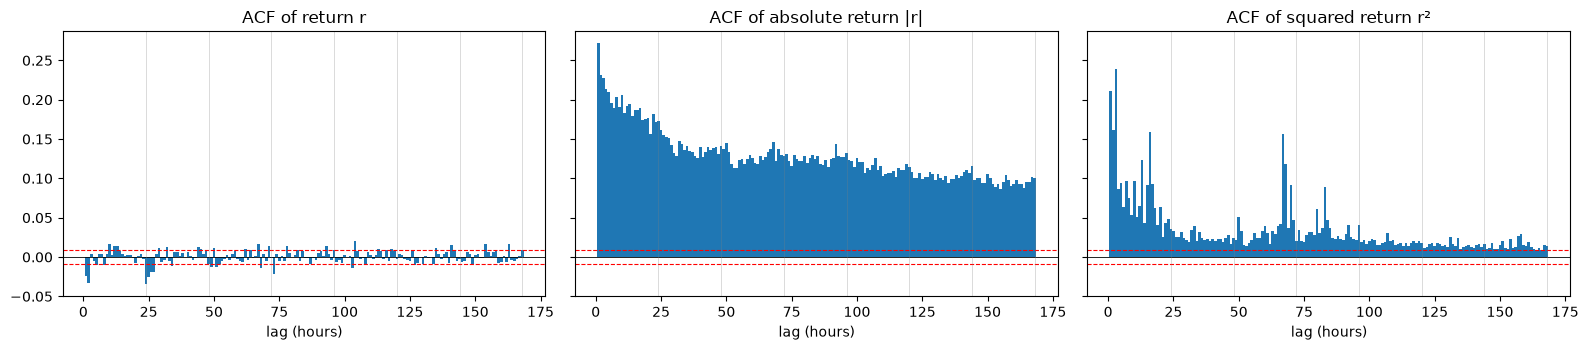

,Q (24 lags),p-value,ACF lag 1,ACF lag 24,sum of ACF² lags 1-24
return r,173.2952,0.0,-0.0244,-0.0349,0.0040
|r|,39466.6008,0.0,0.2716,0.1727,0.9194
r²,11044.0149,0.0,0.2113,0.0359,0.2573


n = 42,913 hours, significance band ±0.0095


In [6]:
tr_hours = hourly.loc[D["train"][0]: D["train"][-1] + pd.Timedelta(hours=24)]
r_tr = tr_hours["Return"]
LAGS = 168

def acf(x, lags):
    x = np.asarray(x, float) - np.mean(x)
    den = (x ** 2).sum()
    return np.array([(x[k:] * x[:-k]).sum() / den for k in range(1, lags + 1)])

acfs = {"return r": acf(r_tr, LAGS), "absolute return |r|": acf(r_tr.abs(), LAGS), "squared return r²": acf(r_tr ** 2, LAGS)}
band = 1.96 / np.sqrt(len(r_tr))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6), sharey=True)
for a, (name, v) in zip(ax, acfs.items()):
    a.bar(range(1, LAGS + 1), v, width=1.0)
    a.axhline(band, ls="--", c="r", lw=0.8); a.axhline(-band, ls="--", c="r", lw=0.8); a.axhline(0, c="k", lw=0.6)
    a.set_title(f"ACF of {name}"); a.set_xlabel("lag (hours)")
    for d in (24, 48, 72, 96, 120, 144, 168):
        a.axvline(d, c="grey", lw=0.4, alpha=0.5)
plt.tight_layout(); plt.show()

lb = pd.DataFrame({name: dict(zip(["Q (24 lags)", "p-value"], U.ljung_box(x, 24)))
                   for name, x in [("return r", r_tr), ("|r|", r_tr.abs()), ("r²", r_tr ** 2)]}).T
lb["ACF lag 1"] = [acfs["return r"][0], acfs["absolute return |r|"][0], acfs["squared return r²"][0]]
lb["ACF lag 24"] = [acfs["return r"][23], acfs["absolute return |r|"][23], acfs["squared return r²"][23]]
lb["sum of ACF² lags 1-24"] = [(acfs[k][:24] ** 2).sum() for k in acfs]
display(lb.round(4))
print(f"n = {len(r_tr):,} hours, significance band ±{band:.4f}")

In [7]:
# AR(24): linear regression of each hour's return on the 24 previous returns
def lag_matrix(r, k=24):
    r = np.asarray(r)
    return np.column_stack([r[k - j - 1: len(r) - j - 1] for j in range(k)]), r[k:]
va_hours = hourly.loc[D["val"][0]: D["val"][-1] + pd.Timedelta(hours=24), "Return"]
Xa, ya = lag_matrix(r_tr); Xv, yv = lag_matrix(va_hours)
for name, target_tr, target_va in [("return r", ya, yv), ("absolute return |r|", np.abs(ya), np.abs(yv))]:
    Xa_, Xv_ = (Xa, Xv) if name == "return r" else (np.abs(Xa), np.abs(Xv))
    ar = Ridge(alpha=1e-6).fit(Xa_, target_tr)
    ins, oos = U.r2(target_tr, ar.predict(Xa_)), U.r2(target_va, ar.predict(Xv_))
    ins0, oos0 = U.r2_oos(target_tr, ar.predict(Xa_)), U.r2_oos(target_va, ar.predict(Xv_))
    print(f"AR(24) on {name:<20}: R² train {ins:+.4f}  validation {oos:+.4f}   "
          f"(R²_oos vs zero: train {ins0:+.4f}, validation {oos0:+.4f})")

AR(24) on return r            : R² train +0.0042  validation -0.0017   (R²_oos vs zero: train +0.0042, validation -0.0012)
AR(24) on absolute return |r| : R² train +0.1734  validation +0.1048   (R²_oos vs zero: train +0.4601, validation +0.4389)


**What we see**

- **Returns (left plot).** Almost all autocorrelations are inside the significance band. A few small negative ones stand out: lag 1 (−0.024), lag 2 and lag 24 (−0.035). These are small **reversals**: after a move, the next hour (and the same hour next day) tends to move slightly the other way. The Ljung–Box test rejects "no dependence" (p ≈ 0), so the effect is real. But it is tiny: the sum of the squared autocorrelations over 24 lags is **0.004**, which means a linear model of the last 24 returns can explain at most ≈0.4% of the variance. The AR(24) model confirms it: R² +0.004 on the train block, **−0.002 on validation**. The dependence is too weak and too unstable to be used.
- **Size of the move (middle plot).** The absolute returns are strongly autocorrelated: 0.27 at lag 1 and still ≈0.10 a full week later (*volatility clustering*, with a long memory). The AR(24) model on |r| explains **10.5% of the validation variance**. (This number is for 1 hour ahead; section 5 predicts 1–24 hours ahead, which is harder.)
- **Squared returns (right plot).** Same message, but noisier: squaring gives enormous weight to a few extreme hours (the isolated spikes, e.g. around lag 67, come from a handful of crash hours). This is why the absolute value |r| is used as the hourly volatility target in section 5.

**Calendar patterns.** Does the time of day or the day of the week matter? The plots show the average return and the average *size* of the move for every hour of the day (UTC) and every weekday, with 95% confidence intervals (train block).

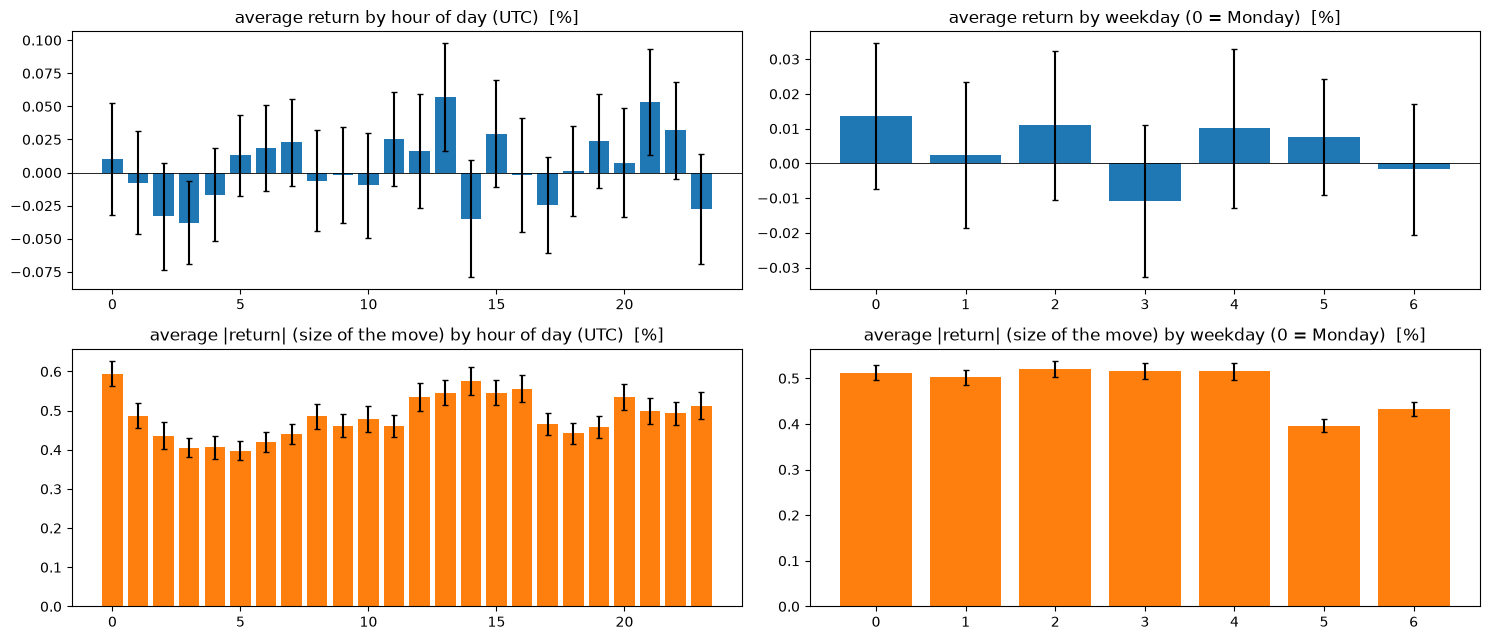

|r| by hour: lowest 0.397% at 5:00, highest 0.594% at 0:00 (ratio 1.50)
|r| weekend / weekdays: 0.81
ANOVA 'mean return equal for all 24 hours': p = 0.011  |  'mean |r| equal for all hours': p = 7.5e-48


In [8]:
cal = pd.DataFrame({"r": r_tr, "abs": r_tr.abs(), "hour": r_tr.index.hour, "dow": r_tr.index.dayofweek})
fig, ax = plt.subplots(2, 2, figsize=(15, 6.5))
for j, key in enumerate(["hour", "dow"]):
    g = cal.groupby(key)
    for i, col in enumerate(["r", "abs"]):
        m, se = g[col].mean(), g[col].std() / np.sqrt(g[col].count())
        ax[i, j].bar(m.index, m.values, yerr=1.96 * se.values, capsize=2, color="C0" if col == "r" else "C1")
        ax[i, j].axhline(0, c="k", lw=0.6)
        ax[i, j].set_title(f"{'average return' if col == 'r' else 'average |return| (size of the move)'} by "
                           f"{'hour of day (UTC)' if key == 'hour' else 'weekday (0 = Monday)'}  [%]")
plt.tight_layout(); plt.show()
prof = cal.groupby("hour")["abs"].mean()
print(f"|r| by hour: lowest {prof.min():.3f}% at {prof.idxmin()}:00, highest {prof.max():.3f}% at {prof.idxmax()}:00 "
      f"(ratio {prof.max() / prof.min():.2f})")
wk = cal.groupby("dow")["abs"].mean()
print(f"|r| weekend / weekdays: {wk[5:].mean() / wk[:5].mean():.2f}")
t_hour = stats.f_oneway(*[g.values for _, g in cal.groupby("hour")["r"]])
t_hour_abs = stats.f_oneway(*[g.values for _, g in cal.groupby("hour")["abs"]])
print(f"ANOVA 'mean return equal for all 24 hours': p = {t_hour.pvalue:.3f}  |  "
      f"'mean |r| equal for all hours': p = {t_hour_abs.pvalue:.1e}")

**What we see in the calendar**

- **Average return by hour:** the bars are all close to 0 and most confidence intervals cross 0. The ANOVA test gives p = 0.011, so some hours differ slightly on average, but the differences are tiny compared with the size of an hourly move (≈0.5%).
- **Size of the move by hour:** a very clear pattern (p ≈ 10⁻⁴⁸). Moves at 00:00 UTC (the daily candle close) are **1.5×** larger than at 05:00 UTC, the quietest hour. Weekend hours move only **0.81×** as much as weekday hours.

**Conclusion of A1, the answer to "why does it look like noise?"**
The **direction** of the next hours is almost pure noise: the only dependence is a tiny reversal effect that explains well under 1% of the variance. No model can turn that into a visible MAE improvement. The **size** of the next hours is clearly predictable from recent volatility, the hour of the day and the weekday. So the problem is not the models: the hourly return target asks the one question the data cannot answer. Sections 5 and 6 ask the questions it *can* answer, and section 7 measures the small return signal with the right tools.

## 5. A6 + A2 — One model for all 24 hours, and a new hourly target: the size of the move

### A6: the long format

Versions 1–2 used "wide" data: one row per origin with 24 targets, so tree models needed `MultiOutputRegressor` (24 separate models, each seeing only 1/24 of the information). In the **long format** every origin becomes 24 rows, one per predicted hour, with extra columns saying *which* hour is predicted:

| Column | Meaning |
|---|---|
| `h_ahead` | 1 … 24: how many hours after the origin |
| `tgt_hour_sin/cos`, `tgt_dow_sin/cos` | hour of day and weekday of the **predicted** hour |

One model then learns what is common to all hours (e.g. "after a volatile week, every hour is volatile") and what is specific to some (e.g. "the hour after the US market opens moves more"). It sees 24× more rows: ≈174,000 instead of 7,250.

**B3: per-hour features** (tested in section 8, defined here because they need the long format):

| Column | Meaning |
|---|---|
| `tgt_weekend` | 1 if the predicted hour is on Saturday/Sunday |
| `tgt_hour_profile` | average size of moves at that hour of day in the train block, divided by the overall average (the intraday pattern of section 4) |
| `absret_same_hour_1d`, `absret_same_hour_7d` | size of the move at the same hour yesterday and one week ago |
| `ret_same_hour_1d` | return at the same hour yesterday (the small lag-24 reversal of section 4) |

### A2: the hourly volatility target

Section 4 shows that the **size** of hourly moves is strongly autocorrelated while the direction is not. So, next to the return target, we predict **|r_h|: the absolute return of each of the 24 next hours**, in %. This keeps the structure of the assigned task (24 hourly values for tomorrow) but asks the question the data can answer: *how much will each hour move?*

The models are trained with squared error, so they predict the expected size of the move. The main metric is the usual **R²** (share of the hour-to-hour variation explained).

**Baselines** (no learning):
- *Training mean*: the same value for every hour.
- *Last week*: the average |r| of the last 168 hours.
- *Same hour yesterday*: |r| 24 hours before the predicted hour.
- *Last week × hour profile*: last week's average |r| multiplied by the intraday pattern. This is the strongest simple rule.

In [9]:
absr = hourly["Return"].abs().values
ret = hourly["Return"].values
H_BASE = ["h_ahead", "tgt_hour_sin", "tgt_hour_cos", "tgt_dow_sin", "tgt_dow_cos"]
B3 = ["tgt_weekend", "tgt_hour_profile", "absret_same_hour_1d", "absret_same_hour_7d", "ret_same_hour_1d"]
HOUR_PROFILE = (tr_hours["Return"].abs().groupby(tr_hours.index.hour).mean() / tr_hours["Return"].abs().mean()).values
week_abs = pd.Series(absr).rolling(168).mean().values                # last week's average |r| at each hour

def Xl(block, cols, hcols=H_BASE):
    """Long format: 24 rows per origin (origin-major order). cols = origin features, hcols = per-hour features."""
    p = P[block]
    n = len(p)
    base = np.repeat(FEAT[cols].values[p], 24, axis=0) if cols else np.empty((n * 24, 0))
    h_ = np.tile(np.arange(1, 25), n)
    tp = np.repeat(p, 24) + h_                                       # position of the predicted hour
    t = hourly.index[np.repeat(p, 24)] + pd.to_timedelta(h_, unit="h")   # (may lie after the end of the series)
    extra = {
        "h_ahead": h_,
        "tgt_hour_sin": np.sin(2 * np.pi * t.hour / 24), "tgt_hour_cos": np.cos(2 * np.pi * t.hour / 24),
        "tgt_dow_sin": np.sin(2 * np.pi * t.dayofweek / 7), "tgt_dow_cos": np.cos(2 * np.pi * t.dayofweek / 7),
        "tgt_weekend": (t.dayofweek >= 5).astype(float),
        "tgt_hour_profile": HOUR_PROFILE[t.hour],
        "absret_same_hour_1d": absr[tp - 24], "absret_same_hour_7d": absr[tp - 168],
        "ret_same_hour_1d": ret[tp - 24],
    }
    return np.hstack([base, np.column_stack([extra[c] for c in hcols])]) if hcols else base

def yl(block, kind="abs"):
    v = Y[block].reshape(-1)
    return np.abs(v) if kind == "abs" else v

def rule_abs(block):
    """Baseline: last week's average |r| x hour-of-day profile of the predicted hour."""
    p = np.repeat(P[block], 24); h_ = np.tile(np.arange(1, 25), len(P[block]))
    return week_abs[p] * HOUR_PROFILE[(hourly.index[p] + pd.to_timedelta(h_, unit="h")).hour]

def vol_scores(y, p):
    return {"score": U.r2(y, p), "MAE": mean_absolute_error(y, p), "corr": U.safe_corr(p, y)}

def abs_baselines(block):
    p = np.repeat(P[block], 24); h_ = np.tile(np.arange(1, 25), len(P[block]))
    return {"Baseline: training mean": np.full(len(p), yl("train").mean()),
            "Baseline: last week": week_abs[p],
            "Baseline: same hour yesterday": absr[p + h_ - 24],
            "Baseline: last week x hour profile": rule_abs(block)}

ya_tr, ya_va = yl("train"), yl("val")
print(f"Long format: train {len(ya_tr):,} rows, validation {len(ya_va):,} rows, test {len(P['test']) * 24:,} rows")
display(pd.DataFrame({k: vol_scores(ya_va, v) for k, v in abs_baselines("val").items()}).T.rename(columns={"score": "R2"}).round(4))

Long format: train 171,576 rows, validation 51,744 rows, test 475,848 rows


,R2,MAE,corr
Baseline: training mean,-0.2226,0.3376,NaN
Baseline: last week,0.0358,0.2308,0.2027
Baseline: same hour yesterday,-0.7479,0.2986,0.1259
Baseline: last week x hour profile,0.0484,0.2283,0.2285


**Baselines on the validation block.** The "last week × hour profile" rule is the best simple rule (R² 0.048). "Same hour yesterday" is very bad (R² −0.75): one single hour is an extremely noisy estimate of volatility. The training mean is also negative (−0.22), because the validation period (2023–mid 2024) was much calmer than 2018–2022: R² penalizes a wrong *level*, not only a wrong pattern.

**Models.** Ridge (linear), Random Forest and HistGradientBoosting, each with a small grid, all on the long format with the *base* features plus the 5 per-hour columns of A6 (the extra feature groups are tested in section 8). The Random Forest uses `max_samples=0.2` (each tree sees a random 20% of the rows), which keeps it fast on 174,000 rows.

In [10]:
XA_tr, XA_va = Xl("train", BASE), Xl("val", BASE)
make_ridge = lambda alpha: make_pipeline(StandardScaler(), Ridge(alpha=alpha))
make_hgb = lambda **p: HistGradientBoostingRegressor(max_iter=300, early_stopping=True, random_state=RANDOM_STATE, **p)
make_rf = lambda **p: RandomForestRegressor(n_estimators=100, max_samples=0.2, max_features=0.3, n_jobs=-1,
                                            random_state=RANDOM_STATE, **p)
abs_ridge_t, p_abs_ridge = tune(make_ridge, {"alpha": [0.01, 1, 100, 10_000, 1_000_000]}, XA_tr, ya_tr, XA_va, ya_va, vol_scores, "Ridge")
abs_hgb_t, p_abs_hgb = tune(make_hgb, {"learning_rate": [0.03, 0.1, 0.2], "max_depth": [2, 3, 6], "min_samples_leaf": [100, 1000, 3000]},
                            XA_tr, ya_tr, XA_va, ya_va, vol_scores, "HGB")
abs_rf_t, p_abs_rf = tune(make_rf, {"max_depth": [8, 14, 20], "min_samples_leaf": [20, 200, 1000]}, XA_tr, ya_tr, XA_va, ya_va, vol_scores, "RF")

,alpha,score,MAE,corr,seconds
0,0.01,0.0889,0.2201,0.2985,0.3
1,1.00,0.0888,0.2201,0.2984,0.3
2,100.00,0.0880,0.2205,0.2970,0.3
3,10000.00,0.0812,0.2262,0.2861,0.3
4,1000000.00,-0.0398,0.2863,0.2419,0.3


,learning_rate,max_depth,min_samples_leaf,score,MAE,corr,seconds
0,0.10,2,1000,0.0916,0.2218,0.3032,2.1
1,0.10,2,3000,0.0913,0.2226,0.3031,2.0
2,0.10,3,1000,0.0904,0.2219,0.3020,2.5
3,0.03,6,3000,0.0903,0.2231,0.3014,3.1
4,0.03,3,100,0.0897,0.2238,0.3006,2.5
5,0.10,3,100,0.0897,0.2218,0.3005,2.1
6,0.03,6,1000,0.0896,0.2231,0.3006,2.8
7,0.10,2,100,0.0896,0.2234,0.3001,1.5
8,0.03,3,3000,0.0894,0.2246,0.3004,2.5
9,0.03,3,1000,0.0893,0.2244,0.3002,2.5


,max_depth,min_samples_leaf,score,MAE,corr,seconds
0,20,200,0.0801,0.2263,0.2842,4.4
1,14,200,0.0799,0.2264,0.2841,3.9
2,8,200,0.0764,0.2274,0.2779,3.6
3,14,20,0.0762,0.2285,0.2808,4.6
4,20,20,0.0755,0.2290,0.2812,5.1
5,8,20,0.0698,0.2301,0.2682,4.0
6,14,1000,0.0671,0.2307,0.2614,3.5
7,20,1000,0.0671,0.2307,0.2614,3.3
8,8,1000,0.0669,0.2308,0.2612,3.0


**Reading the tables.** All three models beat the best rule (0.048) by a wide margin. Gradient Boosting is best on validation (R² 0.092), Ridge is close behind (0.089), Random Forest is lowest (0.080).
- *Ridge:* every alpha ≤ 100 gives the same result, so the best value at the edge of the grid (0.01) is a **plateau**, not a reason to extend.
- *Gradient Boosting:* about 20 of the 27 settings lie within ±0.003 of the best, much less than the differences between periods (section 9). Its best depth (2) is at the lower edge of the grid, but depth 3 scores almost the same (0.090). Sections 11–12 re-tune it with walk-forward CV and a tuned number of trees.
- *Random Forest:* the best depth (20) is at the upper edge, but depth 14 gives the same score (0.080 vs 0.080): another plateau.

**A6 on its own: long vs. wide.** The same HistGradientBoosting setting is trained the old way, with `MultiOutputRegressor` (24 models on the wide data, one per hour), on the same target. Comparing the validation R² and the training time isolates the effect of the long format.

In [11]:
t0 = time.time()
wide = MultiOutputRegressor(make_hgb(**p_abs_hgb)).fit(Xw("train", BASE), np.abs(Y["train"]))
t_wide = time.time() - t0
pred_wide = wide.predict(Xw("val", BASE)).reshape(-1)
t0 = time.time()
long_m = make_hgb(**p_abs_hgb).fit(XA_tr, ya_tr)
t_long = time.time() - t0
pred_long = long_m.predict(XA_va)
display(pd.DataFrame({"wide (24 models)": {**vol_scores(ya_va, pred_wide), "train seconds": t_wide},
                      "long (1 model)": {**vol_scores(ya_va, pred_long), "train seconds": t_long}}).T
        .rename(columns={"score": "val R2"}).round(4))

,val R2,MAE,corr,train seconds
wide (24 models),0.0642,0.2335,0.2632,1.8888
long (1 model),0.0916,0.2218,0.3032,1.7156


**A6 on its own: the long format raises the validation R² from 0.064 to 0.092 (+43%)**, with the same model, the same features and the same training time. The 24 separate models of the wide format each see only their own hour. The single long-format model learns the common structure ("volatile weeks make every hour volatile") from 24× more rows, and the hour-specific part from the per-hour columns.

**Test block.** The best setting of each model is refitted on train + validation and evaluated once on the test block (all 19,800 origins × 24 hours).

,R2,MAE,corr
Baseline: training mean,-0.1943,0.3248,NaN
Baseline: last week,0.0376,0.2371,0.2084
Baseline: same hour yesterday,-0.6834,0.3047,0.1583
Baseline: last week x hour profile,0.0527,0.2351,0.2383
Ridge,0.0946,0.2255,0.3092
Random Forest,0.1078,0.2246,0.3287
Gradient Boosting,0.1165,0.2227,0.3417


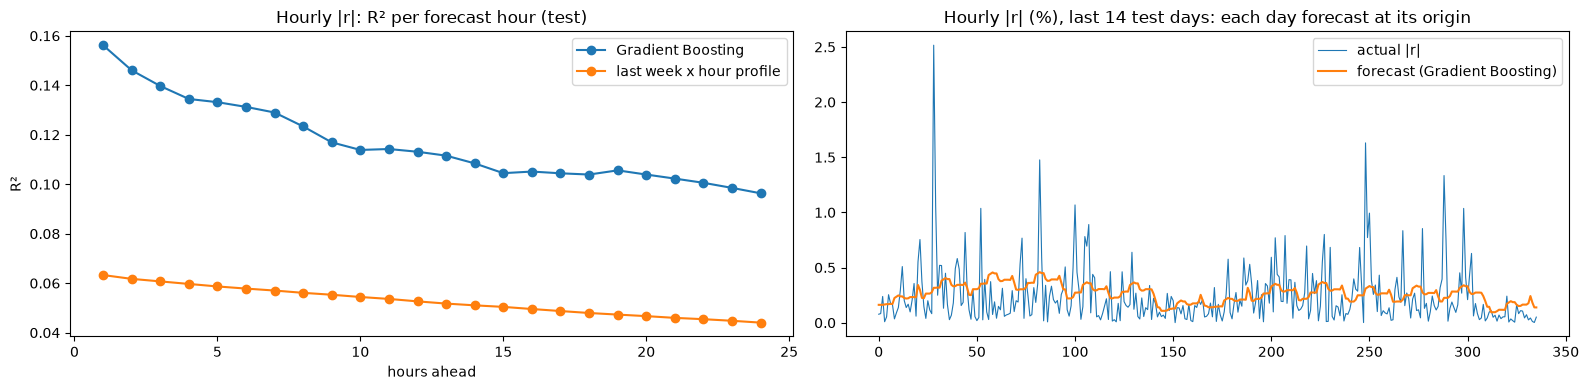

In [12]:
XA_tv, ya_tv = np.vstack([XA_tr, XA_va]), np.r_[ya_tr, ya_va]
XA_te, ya_te = Xl("test", BASE), yl("test")
abs_test_pred = dict(abs_baselines("test"))
for name, m in [("Ridge", make_ridge(**p_abs_ridge)), ("Random Forest", make_rf(**p_abs_rf)),
                ("Gradient Boosting", make_hgb(**p_abs_hgb))]:
    abs_test_pred[f"{name}"] = m.fit(XA_tv, ya_tv).predict(XA_te)
tab = pd.DataFrame({k: vol_scores(ya_te, v) for k, v in abs_test_pred.items()}).T.rename(columns={"score": "R2"})
for k, row in tab.iterrows():
    record("5 A2+A6", "hourly |r|", k + (" (long, base feats)" if not k.startswith("Baseline") else ""),
           R2=row["R2"], MAE=row["MAE"], corr=row["corr"])
display(tab.round(4))

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
best_abs = tab.drop([i for i in tab.index if i.startswith("Baseline")])["R2"].idxmax()
pr = abs_test_pred[best_abs].reshape(-1, 24); ac = ya_te.reshape(-1, 24)
ax[0].plot(range(1, 25), [U.r2(ac[:, k], pr[:, k]) for k in range(24)], "o-", label=best_abs)
rb = abs_test_pred["Baseline: last week x hour profile"].reshape(-1, 24)
ax[0].plot(range(1, 25), [U.r2(ac[:, k], rb[:, k]) for k in range(24)], "o-", label="last week x hour profile")
ax[0].set_xlabel("hours ahead"); ax[0].set_ylabel("R²"); ax[0].set_title("Hourly |r|: R² per forecast hour (test)"); ax[0].legend()
seg = slice(len(P["test"]) - 24 * 14, None, 24)                     # last 14 days, one origin per day
ax[1].plot(np.abs(Y["test"][seg]).reshape(-1), lw=0.8, label="actual |r|")
ax[1].plot(pr[seg].reshape(-1), lw=1.5, label=f"forecast ({best_abs})")
ax[1].set_title("Hourly |r| (%), last 14 test days: each day forecast at its origin"); ax[1].legend()
plt.tight_layout(); plt.show()

**Test block results (A2 + A6).** Gradient Boosting explains **11.7% of the hour-to-hour variation in the size of the move** (Random Forest 10.8%, Ridge 9.5%), about **2.2× the best simple rule** (5.3%). The correlation between forecast and actual size is 0.34.

- **Left plot:** the skill is highest for the next hour (R² ≈ 0.16) and slowly decreases to ≈ 0.10 at 24 hours ahead, as expected: the further ahead, the less the recent volatility tells. The model beats the rule at every horizon.
- **Right plot:** the forecast (orange) follows the calm and agitated periods and the intraday rhythm, but not the individual spikes. Single extreme hours are news-driven and not predictable, which is why R² stays far below 1. An R² of ≈0.12 for *hourly* volatility is a good result.

This is the first version of the 24-hour task where the models produce a clear, measurable improvement.

## 6. A3 — Hourly prediction ranges (quantile regression)

A single number for an almost unpredictable return will always be ≈ 0. A **range** is far more useful: "the next hour will move between −0.6% and +0.6% with 80% probability". It is also honest about uncertainty.

**Quantile regression** predicts a chosen quantile of the return instead of its mean. Three models are trained on the long format:

| Quantile | Meaning |
|---|---|
| q10 | 10% of the hours should fall *below* it |
| q50 | the median: the best single forecast for MAE (the metric of versions 1–2) |
| q90 | 10% of the hours should fall *above* it |

[q10, q90] is an **80% prediction interval**.

Models: `HistGradientBoostingRegressor(loss="quantile")` and the linear `QuantileRegressor` (trained on a random 8,000-row subsample because it solves a large linear program).

**Metrics**
- **Pinball loss**: the loss that a quantile minimizes. Lower is better. It is the standard score for quantile forecasts, comparable only between forecasts of the same quantile.
- **Coverage**: share of hours inside [q10, q90]. Should be ≈ 80%.
- **Width**: average q90 − q10. Narrower is better *at the same coverage*.
- **Coverage by volatility tercile**: coverage on the calmest, middle and wildest third of the hours (by the "last week × profile" rule). A good interval keeps ≈80% in *all* of them. A fixed interval cannot do that.

**Baselines**
- *Fixed*: the 10%/50%/90% quantiles of all training returns, the same every hour.
- *Volatility-scaled*: the training quantiles of r / σ_rule, multiplied by σ_rule of each hour (σ_rule = last week × hour profile). This is a simple but strong rule.

Quantile models can occasionally cross (q10 > q50). We sort the three predictions of each row, which is the standard fix.

In [13]:
TAUS = (0.1, 0.5, 0.9)
yr_tr, yr_va, yr_te = yl("train", "ret"), yl("val", "ret"), yl("test", "ret")
make_q = lambda tau, **p: HistGradientBoostingRegressor(loss="quantile", quantile=tau, max_iter=300, early_stopping=True,
                                                         random_state=RANDOM_STATE, **p)

def interval_scores(y, q, sigma):
    q = np.sort(q, axis=1)
    inside = (y >= q[:, 0]) & (y <= q[:, 2])
    terc = pd.qcut(sigma, 3, labels=["calm", "middle", "wild"])
    out = {f"pinball_q{int(t * 100)}": U.pinball(y, q[:, i], t) for i, t in enumerate(TAUS)}
    out.update({"coverage_80": inside.mean(), "width": (q[:, 2] - q[:, 0]).mean()})
    out.update({f"cov_{c}": inside[terc == c].mean() for c in ["calm", "middle", "wild"]})
    out["MAE_skill_q50"] = 1 - np.abs(y - q[:, 1]).mean() / np.abs(y).mean()
    return out

def quantile_baselines(block):
    s = rule_abs(block)
    fixed = np.quantile(yr_tr, TAUS)
    zq = np.quantile(yr_tr / rule_abs("train"), TAUS)
    return {"Baseline: fixed quantiles": np.tile(fixed, (len(s), 1)), "Baseline: volatility-scaled": s[:, None] * zq}

def q_score(y, p):
    return {"score": -U.pinball(y, p, TAU_NOW)}

q_best = {}
for TAU_NOW in (0.1, 0.9, 0.5):
    _, q_best[TAU_NOW] = tune(lambda **p: make_q(TAU_NOW, **p),
                              {"learning_rate": [0.02, 0.05, 0.1], "max_depth": [2, 3, 6], "min_samples_leaf": [50, 200, 2000]},
                              XA_tr, yr_tr, XA_va, yr_va, q_score, f"q{int(TAU_NOW * 100)}", show=False)
print("best settings per quantile:", q_best)


best settings per quantile: {0.1: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 50}, 0.9: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2000}, 0.5: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 200}}


In [14]:
XA_tv_r = XA_tv
yr_tv = np.r_[yr_tr, yr_va]
q_pred_te = dict(quantile_baselines("test"))
q_pred_te["Gradient Boosting (quantile)"] = np.column_stack([make_q(t, **q_best[t]).fit(XA_tv, yr_tv).predict(XA_te) for t in TAUS])
sub = np.random.default_rng(RANDOM_STATE).choice(len(yr_tv), 8_000, replace=False)
sc_q = StandardScaler().fit(XA_tv[sub])
t0 = time.time()
q_pred_te["Linear quantile regression"] = np.column_stack([
    QuantileRegressor(quantile=t, alpha=0.0, solver="highs").fit(sc_q.transform(XA_tv[sub]), yr_tv[sub]).predict(sc_q.transform(XA_te))
    for t in TAUS])
print(f"linear quantile regression: {time.time() - t0:.0f} s")
s_te = rule_abs("test")
qtab = pd.DataFrame({k: interval_scores(yr_te, v, s_te) for k, v in q_pred_te.items()}).T
for k, row in qtab.iterrows():
    record("6 A3", "hourly quantiles", k, **row.to_dict())
display(qtab.round(4))

linear quantile regression: 40 s


,pinball_q10,pinball_q50,pinball_q90,coverage_80,width,cov_calm,cov_middle,cov_wild,MAE_skill_q50
Baseline: fixed quantiles,0.0951,0.1598,0.0937,0.8956,1.4034,0.9553,0.9024,0.8291,-0.0000
Baseline: volatility-scaled,0.0863,0.1598,0.0846,0.7883,0.9451,0.7792,0.7808,0.8049,0.0000
Gradient Boosting (quantile),0.0834,0.1598,0.0812,0.7700,0.8932,0.7615,0.7684,0.7801,0.0001
Linear quantile regression,0.0858,0.1605,0.0831,0.7709,0.9116,0.7729,0.7673,0.7725,-0.0043


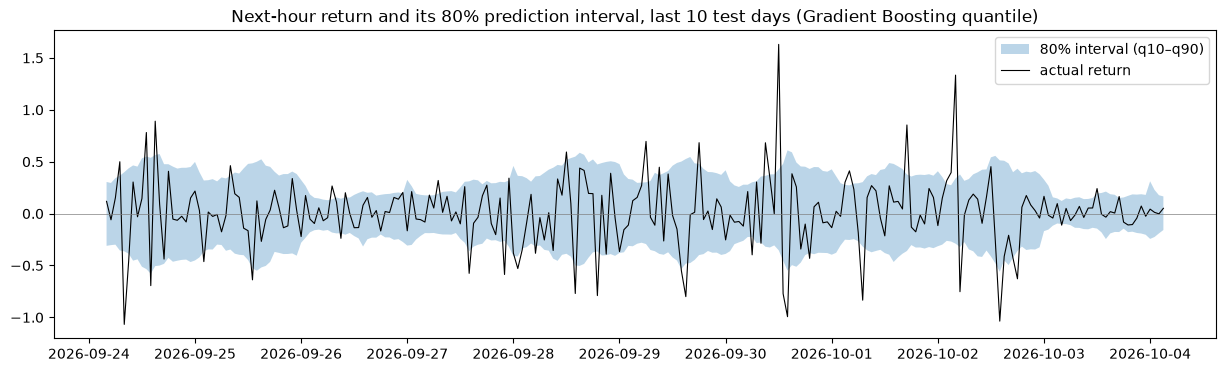

In [15]:
k = "Gradient Boosting (quantile)"
q = np.sort(q_pred_te[k], axis=1)
h1 = np.arange(len(yr_te)) % 24 == 0                            # 1-hour-ahead rows only
idx = np.flatnonzero(h1)[-24 * 10:]
fig, ax = plt.subplots(figsize=(15, 4))
tt = D["test"][idx // 24] + pd.Timedelta(hours=1)
ax.fill_between(tt, q[idx, 0], q[idx, 2], alpha=0.3, label="80% interval (q10–q90)")
ax.plot(tt, yr_te[idx], lw=0.8, c="k", label="actual return")
ax.axhline(0, c="grey", lw=0.5)
ax.set_title("Next-hour return and its 80% prediction interval, last 10 test days (Gradient Boosting quantile)"); ax.legend()
plt.show()

**What we see**

- **Pinball loss:** Gradient Boosting has the lowest loss for q10 (0.0834) and q90 (0.0812), better than the volatility-scaled rule (0.0863 / 0.0846) and much better than fixed quantiles (0.0951 / 0.0937). The linear quantile regression lies in between.
- **Width:** the model's 80% interval is on average **0.89%** wide, against **1.40%** for the fixed one: **36% narrower**.
- **Conditional coverage** is the clearest result. The fixed interval covers 95.5% of the calm hours (far too wide) but only 82.9% of the wild ones. The model stays at **76–78% in every volatility tercile**, so its width adapts to the market.
- **Overall coverage is 77%, a little below the 80% target.** The test period behaves slightly differently from the training years, and quantile models trained on past data are known to be slightly over-confident. A simple fix is listed in the ideas (section 16).
- **The median (q50) has MAE skill ≈ 0** (0.0001): the best "single number" for the next hour is still ≈ 0%. The plot shows the same: the band widens and narrows with the market, while its centre stays at 0.

**Conclusion of A3:** for hourly returns, the *centre* of the forecast is unpredictable, but the **range** is predictable and can be stated honestly. That is a useful and correct answer to the 24-hour task.

*Hyperparameters:* the best settings per quantile lie partly on grid edges (depth 2, learning rate 0.1, leaf 50 or 2000), but all neighbouring settings are within 0.0005 pinball loss. Section 12.4 re-tunes them with walk-forward CV and gets the same test result.

## 7. A4 — Fixing the metric mismatch for the return forecasts

Versions 1–2 trained the return models with **squared error** (they learn the *mean*), but chose and judged them by **MAE**, which is minimized by the *median*. For hourly returns the median is ≈ 0, so any forecast that moves away from 0, even in the right direction, makes MAE slightly worse. A weak but real signal is therefore invisible: in version 2, Ridge with a small penalty had a positive validation IC (+0.02) but a negative MAE skill, and the MAE choice threw it away.

**Changes**
1. **Choose by a metric that matches the loss.** For squared-error models that is **R²_oos** (1 − SSE/SSE_zero). The IC (correlation) is shown as a second option: it ignores the scale of the forecast and only asks "are the hours ranked correctly?".
2. **A proper significance test against the zero forecast: Diebold–Mariano.** For every independent test day we compute the loss of the model and of the zero forecast, average over the 24 hours, and test whether the mean difference is > 0. The standard error uses Newey–West (robust to the autocorrelation between days). The test is run for squared error and for absolute error.
3. **Confident forecasts.** A model can be useful even if it is only right when it "speaks loudly". On the independent test days (each actual hour counted once) we take the 10% of hours with the largest |forecast| and check the direction accuracy there, with a binomial test, plus the balanced accuracy (so that "always up" cannot look good).

The models use the long format of section 5 (one model for all 24 hours, base features + per-hour columns). The version-2 setup (HistGradientBoosting with `MultiOutputRegressor`, MAE loss, chosen by MAE skill) is refitted as a reference.

In [16]:
def ret_scores(y, p):
    return {"score": U.r2_oos(y, p), "MAE_skill": 1 - np.abs(y - p).mean() / np.abs(y).mean(), "IC": U.safe_corr(p, y)}

def pick(table, col, keys):
    row = table.loc[table[col].idxmax(), keys]
    return {k: (int(v) if k in ("max_depth", "min_samples_leaf", "max_iter") else v.item() if isinstance(v, np.generic) else v)
            for k, v in row.items()}

ret_ridge_t, _ = tune(make_ridge, {"alpha": [0.1, 10, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]},
                      XA_tr, yr_tr, XA_va, yr_va, ret_scores, "Ridge")
ret_hgb_t, _ = tune(make_hgb, {"learning_rate": [0.01, 0.03, 0.1, 0.3], "max_depth": [1, 2, 4, 6], "min_samples_leaf": [200, 2000, 5000]},
                    XA_tr, yr_tr, XA_va, yr_va, ret_scores, "HGB", show=False)
display(ret_hgb_t.head(8).round(4))
choices = {}
for name, t, keys in [("Ridge", ret_ridge_t, ["alpha"]), ("HGB", ret_hgb_t, ["learning_rate", "max_depth", "min_samples_leaf"])]:
    for crit in ["MAE_skill", "score", "IC"]:
        choices[(name, crit)] = pick(t, crit, keys)
display(pd.DataFrame({f"{n} by {'R2_oos' if c == 'score' else c}": v for (n, c), v in choices.items()}).T)

,alpha,score,MAE_skill,IC,seconds
0,100000000.0,0.0004,0.0003,0.0095,0.3
1,10000000.0,0.0003,0.0003,0.0098,0.3
2,1000000.0,0.0003,0.0002,0.0116,0.3
3,100000.0,0.0001,-0.0002,0.0121,0.3
4,10000.0,-0.0005,-0.0008,0.0110,0.3
5,1000.0,-0.0006,-0.0010,0.0104,0.3
6,10.0,-0.0006,-0.0010,0.0102,0.3
7,0.1,-0.0006,-0.0010,0.0102,0.3


,learning_rate,max_depth,min_samples_leaf,score,MAE_skill,IC,seconds
0,0.03,6,2000,0.0006,0.0003,0.0197,1.0
1,0.01,6,200,0.0006,0.0003,0.0169,1.7
2,0.03,6,200,0.0006,0.0003,0.0164,1.0
3,0.10,4,2000,0.0006,0.0002,0.0180,0.8
4,0.01,4,200,0.0005,0.0004,0.0169,1.3
5,0.30,2,200,0.0005,0.0002,0.0168,0.8
6,0.03,4,200,0.0005,0.0003,0.0148,1.0
7,0.01,6,5000,0.0005,0.0004,0.0166,0.8


,alpha,learning_rate,max_depth,min_samples_leaf
Ridge by MAE_skill,10000000.0,NaN,NaN,NaN
Ridge by R2_oos,100000000.0,NaN,NaN,NaN
Ridge by IC,100000.0,NaN,NaN,NaN
HGB by MAE_skill,NaN,0.01,4.0,200.0
HGB by R2_oos,NaN,0.03,6.0,2000.0
HGB by IC,NaN,0.03,6.0,2000.0


**Different criteria choose different models.** For Ridge, MAE skill and R²_oos both prefer an enormous penalty (alpha 10⁷–10⁸, i.e. a forecast ≈ the training average), while the IC prefers alpha = 10⁵, which keeps some information. For Gradient Boosting, MAE skill picks a cautious model (learning rate 0.01), while R²_oos and IC pick a deeper one (depth 6, leaf 2000). Note how close everything is: the whole HGB table lies within 0.0002 of R²_oos. Validation can barely tell these settings apart. (Ridge's alpha = 10⁸ is at the edge of the grid, but alphas 10⁶–10⁸ are a plateau.)

**Test block.** Each choice is refitted on train + validation and evaluated once. Columns:
- `MAE_skill`, `R2_oos`, `IC`: as in versions 1–2.
- `DM_p_sq` / `DM_p_abs`: Diebold–Mariano p-value for "the model has a lower squared / absolute error than the zero forecast" (independent days).
- `conf_n`, `conf_acc`, `conf_bal_acc`, `conf_p`: number of hours, direction accuracy, balanced accuracy and binomial p-value on the 10% most confident hourly forecasts (independent days only).

*Why only independent days?* In the test block each actual hour appears in 24 rows (it is hour 1 of one origin, hour 2 of the previous one, …). Counting it 24 times would make a binomial test far too confident.

In [17]:
def daily_loss(y, p, kind):
    e = (y - p) ** 2 if kind == "sq" else np.abs(y - p)
    return e.reshape(-1, 24)[test_days].mean(axis=1)                   # one loss per independent test day

def ret_test_report(name, pred, section="7 A4", target="hourly returns"):
    y = yr_te
    m = ret_scores(y, pred)
    out = {"MAE_skill": m["MAE_skill"], "R2_oos": m["score"], "IC": m["IC"]}
    for kind in ("sq", "abs"):                                          # (not defined for the zero forecast itself)
        out[f"DM_p_{kind}"] = np.nan if not pred.any() else \
            U.diebold_mariano(daily_loss(y, 0 * pred, kind), daily_loss(y, pred, kind))[2]
    # confident forecasts, on independent days only (every actual hour counted once)
    ind = (test_days[:, None] * 24 + np.arange(24)).ravel()
    pi, yi = pred[ind], y[ind]
    top = (np.abs(pi) >= np.quantile(np.abs(pi), 0.9)) & (yi != 0) & (pi != 0)
    hits = np.sign(pi[top]) == np.sign(yi[top])
    out["conf_n"] = int(top.sum())
    out["conf_acc"] = hits.mean() if top.any() else np.nan
    out["conf_bal_acc"] = balanced_accuracy_score(yi[top] > 0, pi[top] > 0) if top.any() else np.nan
    out["conf_p"] = stats.binomtest(int(hits.sum()), int(top.sum()), 0.5, alternative="greater").pvalue if top.any() else np.nan
    record(section, target, name, **out)
    return out

ret_pred_te = {}
yr_tv = np.r_[yr_tr, yr_va]
ret_rows = {"Baseline: zero": ret_test_report("Baseline: zero", np.zeros_like(yr_te))}
# version-2 reference: wide MultiOutput HGB with MAE loss, chosen by MAE skill in version 2
v2_ref = MultiOutputRegressor(HistGradientBoostingRegressor(loss="absolute_error", learning_rate=0.03, max_depth=1, max_iter=200,
                              min_samples_leaf=200, early_stopping=True, random_state=RANDOM_STATE))
ret_pred_te["v2 reference (wide HGB, MAE)"] = v2_ref.fit(np.vstack([Xw("train", BASE), Xw("val", BASE)]),
                                                         np.vstack([Y["train"], Y["val"]])).predict(Xw("test", BASE)).reshape(-1)
for (name, crit), p in choices.items():
    label = f"{name} chosen by {'R2_oos' if crit == 'score' else crit} {p}"
    m = make_ridge(**p) if name == "Ridge" else make_hgb(**p)
    ret_pred_te[label] = m.fit(XA_tv, yr_tv).predict(XA_te)
for k, v in ret_pred_te.items():
    ret_rows[k] = ret_test_report(k, v)
display(pd.DataFrame(ret_rows).T.round(4))

,MAE_skill,R2_oos,IC,DM_p_sq,DM_p_abs,conf_n,conf_acc,conf_bal_acc,conf_p
Baseline: zero,0.0000,0.0000,NaN,NaN,NaN,0.0,NaN,NaN,NaN
"v2 reference (wide HGB, MAE)",-0.0002,-0.0006,0.0049,0.8750,0.5577,1982.0,0.5207,0.5141,0.0344
Ridge chosen by MAE_skill {'alpha': 10000000.0},-0.0000,0.0000,0.0127,0.4332,0.4694,1983.0,0.5169,0.5000,0.0691
Ridge chosen by R2_oos {'alpha': 100000000.0},-0.0000,-0.0000,0.0126,0.5070,0.5445,1983.0,0.5108,0.5000,0.1728
Ridge chosen by IC {'alpha': 100000.0},-0.0002,0.0000,0.0104,0.3723,0.6453,1979.0,0.5174,0.5058,0.0632
"HGB chosen by MAE_skill {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 200}",0.0000,-0.0000,0.0025,0.4531,0.4500,2006.0,0.5105,0.5000,0.1800
"HGB chosen by R2_oos {'learning_rate': 0.03, 'max_depth': 6, 'min_samples_leaf': 2000}",-0.0002,0.0004,0.0198,0.1257,0.4088,1979.0,0.5164,0.5102,0.0751
"HGB chosen by IC {'learning_rate': 0.03, 'max_depth': 6, 'min_samples_leaf': 2000}",-0.0002,0.0004,0.0198,0.1257,0.4088,1979.0,0.5164,0.5102,0.0751


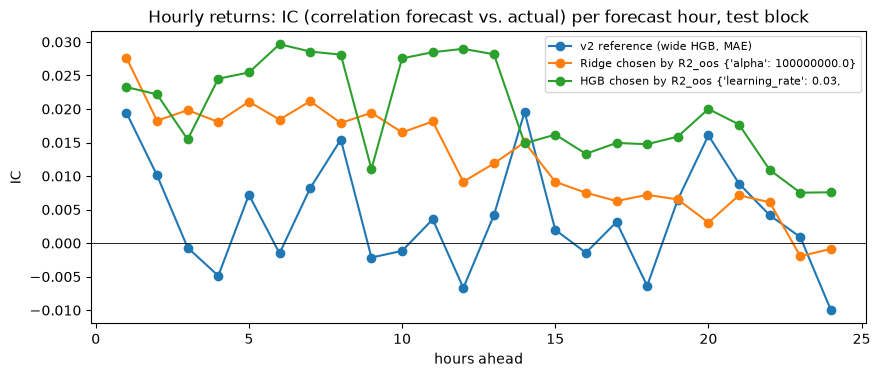

In [18]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for k, v in ret_pred_te.items():
    if "R2_oos" in k or "v2" in k:
        pr, ac = v.reshape(-1, 24), yr_te.reshape(-1, 24)
        ax.plot(range(1, 25), [U.safe_corr(pr[:, j], ac[:, j]) for j in range(24)], "o-", label=k[:45])
ax.axhline(0, c="k", lw=0.6); ax.set_xlabel("hours ahead"); ax.set_ylabel("IC"); ax.legend(fontsize=8)
ax.set_title("Hourly returns: IC (correlation forecast vs. actual) per forecast hour, test block"); plt.show()

**What we see on the test block**

- **Choosing by R²_oos/IC helps a little.** The Gradient Boosting chosen by R²_oos is the only return model with a positive R²_oos (+0.0004), and its IC is **0.020**, four times the version-2 reference (0.005). The IC plot shows it positive at every horizon (0.01–0.03), while the reference jumps around 0.
- **It is still not significant.** The Diebold–Mariano test against the zero forecast gives p = 0.13 (squared error) and 0.41 (absolute error).
- **Confident forecasts:** on the 10% most confident hours, accuracy is 51–52% and balanced accuracy 50–51%. The version-2 reference reaches p = 0.03, but it mostly predicts "up" (balanced accuracy 0.514), and with 8 models tested one p-value of 0.03 is expected by pure chance (multiple testing).

**Conclusion of A4:** the metric mismatch was real. With the matching criterion the models keep a small positive signal (IC ≈ 0.02) instead of throwing it away. But the signal is far too small to be statistically reliable on 827 test days. The honest summary for hourly returns is: *weak positive ranking information, not significant.*

## 8. B1–B4 — Better features, one group at a time

Each feature group is added **on its own** to the base features, then all together, with the hyperparameters fixed (taken from sections 5 and 7). Only the inputs change, so the difference in validation score is the effect of the features. Four targets are compared:

| Target | Format | Model | Metric |
|---|---|---|---|
| hourly \|r\| (A2) | long | Gradient Boosting | R² |
| hourly returns | long | Ridge (alpha chosen by R²_oos in section 7) | R²_oos and IC |
| next-day log volatility (version 2, target C) | wide | Gradient Boosting (lr 0.1, depth 2, leaf 20, the setting chosen in version 2) | R² |
| next-day log return (version 2, target A) | wide | Ridge (alpha 100,000, as chosen in version 2) | R²_oos and IC |

B3 (per-hour features) only exists in the long format.

In [19]:
yd_tr, yd_va, yd_te = U.day_log_vol(Y["train"]), U.day_log_vol(Y["val"]), U.day_log_vol(Y["test"])[test_days]
yA_tr, yA_va, yA_te = U.day_log_return(Y["train"]), U.day_log_return(Y["val"]), U.day_log_return(Y["test"])[test_days]
make_dvol = lambda: HistGradientBoostingRegressor(learning_rate=0.1, max_depth=2, min_samples_leaf=20, early_stopping=True,
                                                  random_state=RANDOM_STATE)
p_ret_ridge = choices[("Ridge", "score")]
SETS = {"base": (BASE, H_BASE), "base + B1": (BASE + B1, H_BASE), "base + B2": (BASE + B2, H_BASE),
        "base + B3": (BASE, H_BASE + B3), "all (B1+B2+B3)": (BASE + B1 + B2, H_BASE + B3)}
rows = []
for name, (cols, hcols) in SETS.items():
    t0 = time.time()
    Xtr_l, Xva_l = Xl("train", cols, hcols), Xl("val", cols, hcols)
    r = {"features": name, "n_features": Xtr_l.shape[1]}
    r["hourly|r| R2"] = U.r2(ya_va, make_hgb(**p_abs_hgb).fit(Xtr_l, ya_tr).predict(Xva_l))
    pr = make_ridge(**p_ret_ridge).fit(Xtr_l, yr_tr).predict(Xva_l)
    r["hourly ret R2_oos"], r["hourly ret IC"] = U.r2_oos(yr_va, pr), U.safe_corr(pr, yr_va)
    if name != "base + B3":
        Xtr_w, Xva_w = Xw("train", cols), Xw("val", cols)
        r["day vol R2"] = U.r2(yd_va, make_dvol().fit(Xtr_w, yd_tr).predict(Xva_w))
        pa = make_ridge(alpha=100_000).fit(Xtr_w, yA_tr).predict(Xva_w)
        r["day ret R2_oos"], r["day ret IC"] = U.r2_oos(yA_va, pa), U.safe_corr(pa, yA_va)
    rows.append(r)
    print(f"  {name}: {time.time() - t0:.0f}s", end="\r")
feat_ablation = pd.DataFrame(rows).set_index("features")
display(feat_ablation.round(4))

,n_features,hourly|r| R2,hourly ret R2_oos,hourly ret IC,day vol R2,day ret R2_oos,day ret IC
features,,,,,,,
base,47,0.0916,0.0004,0.0095,0.4171,0.0018,0.0444
base + B1,54,0.0925,0.0004,0.0089,0.3942,0.0011,0.0373
base + B2,53,0.0840,0.0004,0.0085,0.3702,0.0005,0.0394
base + B3,52,0.0915,0.0004,0.0159,NaN,NaN,NaN
all (B1+B2+B3),65,0.0867,0.0004,0.0124,0.3704,0.0000,0.0336


**What we see on the single validation block**

- **B1 (30-day history) and B2 (range-based volatility) do not help.** For next-day volatility they even seem to *hurt* (0.417 → 0.394 / 0.370). That is surprising, because they are classic volatility predictors. The likely reason is that the base features already contain the same information (std of returns over 24/72/168 h, High–Low range), and more correlated features give the trees more ways to fit noise.
- **B3 (per-hour features) raises the IC of the hourly returns from 0.010 to 0.016** and leaves the volatility score unchanged. The likely useful part is `ret_same_hour_1d`, the reversal at lag 24 found in section 4 (ElasticNet in section 11 keeps it).
- Section 9 repeats this comparison with walk-forward CV, because one validation block is too noisy to judge differences of this size.

### B4 — Feature selection with permutation importance

**Permutation importance** measures how much the validation score drops when one feature's values are randomly shuffled (which destroys its information while keeping its distribution). Unlike the Random Forest's built-in importance (section 7.4 of version 1), it is computed on data the model has *not* seen, so a feature that the model only uses to fit noise gets an importance ≈ 0 or below.

It is computed for the "all features" Gradient Boosting models of the two volatility targets (5 shuffles per feature; the hourly model on a 20,000-row sample of the validation block). Features whose average importance is **not above 0** are removed, and the model is retrained on the rest to check that nothing is lost.

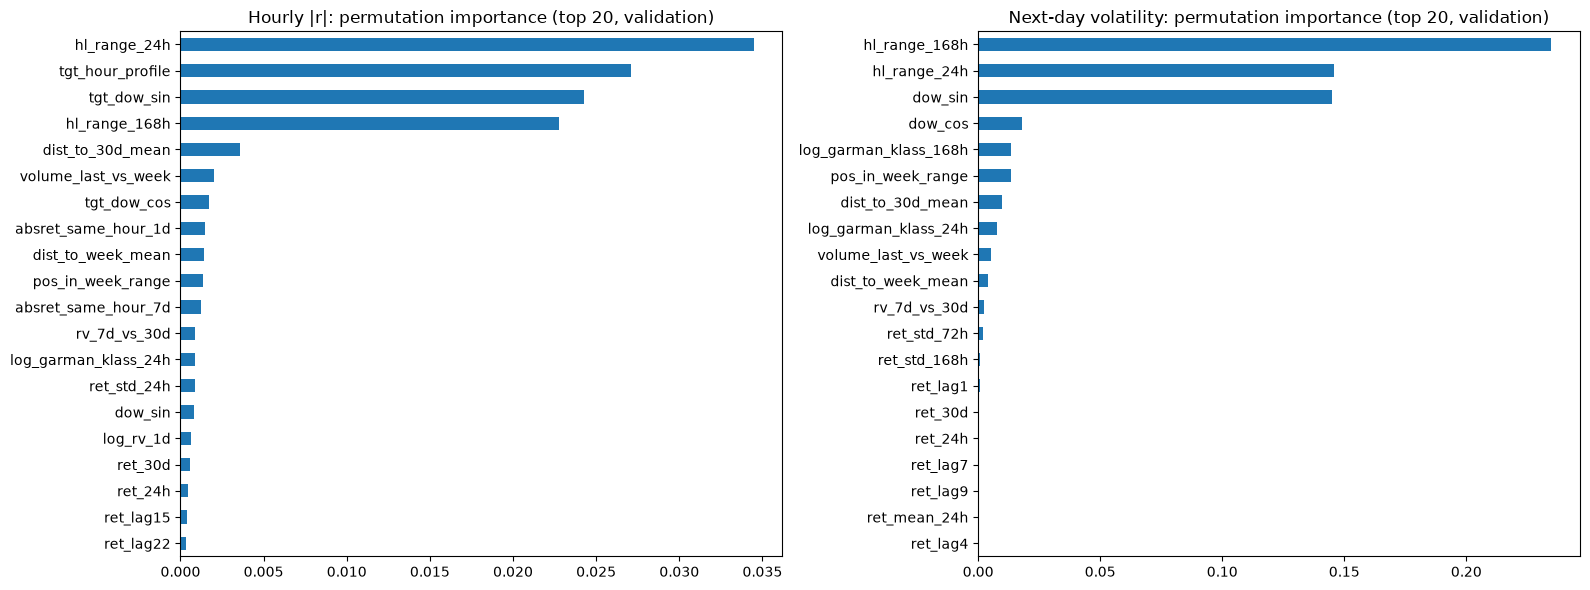

,features (all),val R2 (all),features kept,val R2 (kept)
hourly |r|,65.0,0.0867,44.0,0.0961
next-day volatility,55.0,0.3704,27.0,0.3999


Removed for hourly |r|: ['ret_lag2', 'ret_lag5', 'ret_lag10', 'ret_lag11', 'ret_lag13', 'ret_lag17', 'ret_lag19', 'ret_mean_72h', 'ret_mean_168h', 'ret_std_168h', 'hour_sin', 'hour_cos', 'log_rv_7d', 'log_rv_30d', 'ret_std_720h', 'log_parkinson_168h', 'log_garman_klass_168h', 'log_parkinson_720h', 'log_garman_klass_720h', 'tgt_hour_cos', 'tgt_weekend']
Removed for next-day volatility: ['ret_lag3', 'ret_lag5', 'ret_lag10', 'ret_lag11', 'ret_lag13', 'ret_lag14', 'ret_lag15', 'ret_lag16', 'ret_lag17', 'ret_lag18', 'ret_lag19', 'ret_lag20', 'ret_lag21', 'ret_lag22', 'ret_lag23', 'ret_lag24', 'ret_std_24h', 'ret_mean_168h', 'volume_24h_vs_week', 'hour_sin', 'hour_cos', 'log_rv_1d', 'log_rv_7d', 'log_rv_30d', 'log_parkinson_24h', 'log_parkinson_168h', 'log_parkinson_720h', 'log_garman_klass_720h']


In [20]:
ALL_W, ALL_H = BASE + B1 + B2, H_BASE + B3
Xtr_all_l, Xva_all_l = Xl("train", ALL_W, ALL_H), Xl("val", ALL_W, ALL_H)
names_l = ALL_W + ALL_H
sub_va = np.random.default_rng(1).choice(len(ya_va), 20_000, replace=False)
m_abs_all = make_hgb(**p_abs_hgb).fit(Xtr_all_l, ya_tr)
pi_abs = permutation_importance(m_abs_all, Xva_all_l[sub_va], ya_va[sub_va], scoring="r2", n_repeats=5,
                                random_state=RANDOM_STATE, n_jobs=1)
m_dvol_all = make_dvol().fit(Xw("train", ALL_W), yd_tr)
pi_dvol = permutation_importance(m_dvol_all, Xw("val", ALL_W), yd_va, scoring="r2", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp_abs = pd.Series(pi_abs.importances_mean, index=names_l).sort_values()
imp_dvol = pd.Series(pi_dvol.importances_mean, index=ALL_W).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
imp_abs.tail(20).plot.barh(ax=ax[0], title="Hourly |r|: permutation importance (top 20, validation)")
imp_dvol.tail(20).plot.barh(ax=ax[1], title="Next-day volatility: permutation importance (top 20, validation)")
plt.tight_layout(); plt.show()

SEL_H = [c for c in names_l if imp_abs[c] > 0]
SEL_DVOL = [c for c in ALL_W if imp_dvol[c] > 0]
sel_cols_l = [names_l.index(c) for c in SEL_H]
r_sel_abs = U.r2(ya_va, make_hgb(**p_abs_hgb).fit(Xtr_all_l[:, sel_cols_l], ya_tr).predict(Xva_all_l[:, sel_cols_l]))
r_sel_dvol = U.r2(yd_va, make_dvol().fit(Xw("train", SEL_DVOL), yd_tr).predict(Xw("val", SEL_DVOL)))
display(pd.DataFrame({
    "hourly |r|": {"features (all)": len(names_l), "val R2 (all)": U.r2(ya_va, m_abs_all.predict(Xva_all_l)),
                   "features kept": len(SEL_H), "val R2 (kept)": r_sel_abs},
    "next-day volatility": {"features (all)": len(ALL_W), "val R2 (all)": U.r2(yd_va, m_dvol_all.predict(Xw("val", ALL_W))),
                            "features kept": len(SEL_DVOL), "val R2 (kept)": r_sel_dvol}}).T.round(4))
print("Removed for hourly |r|:", [c for c in names_l if c not in SEL_H])
print("Removed for next-day volatility:", [c for c in ALL_W if c not in SEL_DVOL])

**What we see.** For both targets the most important inputs are the **average High–Low range** of the last 24 hours and of the last week, plus the **calendar**: the hour-of-day profile and the weekday of the predicted hour (hourly target), and the weekday (next-day volatility, because weekends are calm). Everything else is small, and most individual lagged returns get importance ≈ 0. Removing the features with importance ≤ 0 **raises** the validation R² (hourly |r|: 0.087 → 0.096; next-day volatility: 0.370 → 0.400), confirming that the extra features mostly added noise.

**Two cautions.** (1) Permutation importance is unreliable for *correlated* features: if two features carry the same information, shuffling one barely hurts because the other takes over, so both look unimportant. That is why several new volatility features are "removed" although volatility is the key information. (2) The same validation block was used to select and to score, so the "kept" scores are optimistic. For these reasons, the final combinations (section 12) choose feature *groups* with walk-forward CV, not these individual lists.

## 9. C1 + C2 — Walk-forward validation inside train + validation, and time-aware early stopping

### C1: walk-forward cross-validation

Version 2 chose hyperparameters on **one** validation block (≈540 days). For the next-day return it picked an extreme setting that then failed on test. Version 1 used walk-forward CV on the training period. Here we combine the two: **4 walk-forward folds over train + validation (Feb 2018 → Jun 2024)**, with a gap of 32 origins (= 192 hours) before each validation fold, and the test block stays untouched.

Each setting is scored by the **average over the 4 folds**, and the spread across folds (std) shows how stable it is. For the long format, the folds are made of *origins*, and each origin brings its 24 rows with it, so the 24 hours of one forecast never end up on both sides.

The comparison is made on the two daily targets of version 2 that are cheap to fit (next-day log return and log volatility) and on hourly |r|: for each, the best setting according to the single block and according to walk-forward, and how both do on the test block.

In [21]:
n_tr, n_va = len(P["train"]), len(P["val"])
WF = list(TimeSeriesSplit(n_splits=4, gap=int(np.ceil(192 / STRIDE))).split(np.arange(n_tr + n_va)))
SINGLE = [(np.arange(n_tr), np.arange(n_tr, n_tr + n_va))]
tv_dates = D["train"].append(D["val"])
for k, (a, b) in enumerate(WF, 1):
    print(f"fold {k}: train {tv_dates[a[0]].date()} -> {tv_dates[a[-1]].date()} ({len(a)})  |  "
          f"validate {tv_dates[b[0]].date()} -> {tv_dates[b[-1]].date()} ({len(b)})")
rows24 = lambda idx: (np.asarray(idx)[:, None] * 24 + np.arange(24)).ravel()

def cv_tune(make_model, grid, X, y, folds, score_fn, long=False, label="", show=True):
    """Average score over folds (each fold: fit on its train part, score on its validation part)."""
    out, grid = [], list(ParameterGrid(grid))
    for n, p in enumerate(grid, 1):
        t0, sc = time.time(), []
        for a, b in folds:
            a, b = (rows24(a), rows24(b)) if long else (a, b)
            sc.append(score_fn(y[b], make_model(**p).fit(X[a], y[a]).predict(X[b]))["score"])
        out.append({**p, "score": np.mean(sc), "score_std": np.std(sc, ddof=1) if len(sc) > 1 else np.nan,
                    **{f"fold{i + 1}": s for i, s in enumerate(sc)}, "seconds": round(time.time() - t0, 1)})
        print(f"  {label} [{n}/{len(grid)}] {p} score={np.mean(sc):+.4f}", end="\r", flush=True)
    print()
    t = pd.DataFrame(out).sort_values("score", ascending=False).reset_index(drop=True)
    if show:
        display(t.round(4))
    return t, {k: (v.item() if isinstance(v, np.generic) else v) for k, v in t.iloc[0][list(grid[0])].items()}

def as_int(p):
    return {k: (int(v) if k in ("max_depth", "min_samples_leaf", "max_iter", "n_neighbors") else v) for k, v in p.items()}

XW_tv = np.vstack([Xw("train", BASE), Xw("val", BASE)])
XW_te = Xw("test", BASE)[test_days]
yA_tv, yd_tv = np.r_[yA_tr, yA_va], np.r_[yd_tr, yd_va]
r2s = lambda y, p: {"score": U.r2(y, p)}
r2o = lambda y, p: {"score": U.r2_oos(y, p)}
GRID_D = {"learning_rate": [0.03, 0.1, 0.3], "max_depth": [1, 2, 4], "min_samples_leaf": [20, 100, 300]}
c1_rows = []
for tname, y_tv, y_te, scorer, metric in [("next-day log return", yA_tv, yA_te, r2o, "R2_oos"),
                                          ("next-day log volatility", yd_tv, yd_te, r2s, "R2")]:
    mk = lambda **p: HistGradientBoostingRegressor(early_stopping=True, random_state=RANDOM_STATE, **p)
    t_single, p_single = cv_tune(mk, GRID_D, XW_tv, y_tv, SINGLE, scorer, label=f"{tname} single", show=False)
    t_wf, p_wf = cv_tune(mk, GRID_D, XW_tv, y_tv, WF, scorer, label=f"{tname} walk-forward", show=False)
    for how, p in [("single block", p_single), ("walk-forward", p_wf)]:
        p = as_int(p)
        pred = mk(**p).fit(XW_tv, y_tv).predict(XW_te)
        test_score = U.r2_oos(y_te, pred) if metric == "R2_oos" else U.r2(y_te, pred)
        wf_row = t_wf.set_index(list(GRID_D)).loc[tuple(p[k] for k in GRID_D)]
        c1_rows.append({"target": tname, "chosen by": how, "params": p, "walk-forward score": wf_row["score"],
                        "walk-forward std": wf_row["score_std"], f"test {metric}": test_score,
                        "test IC": U.safe_corr(pred, y_te)})
        record("9 C1", tname, f"HGB chosen by {how} {p}", **{metric: test_score, "IC": U.safe_corr(pred, y_te)})
display(pd.DataFrame(c1_rows).round(4))

fold 1: train 2018-01-30 -> 2019-05-02 (1829)  |  validate 2019-05-11 -> 2020-08-18 (1861)
fold 2: train 2018-01-30 -> 2020-08-10 (3690)  |  validate 2020-08-18 -> 2021-11-26 (1861)
fold 3: train 2018-01-30 -> 2021-11-18 (5551)  |  validate 2021-11-26 -> 2023-03-14 (1861)
fold 4: train 2018-01-30 -> 2023-03-06 (7412)  |  validate 2023-03-14 -> 2024-06-21 (1861)


,target,chosen by,params,walk-forward score,walk-forward std,test R2_oos,test IC,test R2
0,next-day log return,single block,"{'learning_rate': 0.3, 'max_depth': 1, 'min_sa...",-0.0041,0.0043,-0.0023,0.0047,NaN
1,next-day log return,walk-forward,"{'learning_rate': 0.03, 'max_depth': 2, 'min_s...",0.0034,0.0108,0.0037,0.0671,NaN
2,next-day log volatility,single block,"{'learning_rate': 0.3, 'max_depth': 2, 'min_sa...",0.4455,0.0351,NaN,0.6802,0.4626
3,next-day log volatility,walk-forward,"{'learning_rate': 0.1, 'max_depth': 2, 'min_sa...",0.4555,0.0426,NaN,0.6921,0.4777


**What we see**

- **Next-day return:** the single block picks an extreme setting (learning rate 0.3, depth 1) that is negative on the walk-forward folds (−0.004) and on test (R²_oos −0.002). Walk-forward picks a cautious one (learning rate 0.03, depth 2) that is positive on the folds (+0.003) **and on test (+0.004, IC 0.067)**. This is exactly the failure of version 2, and walk-forward fixes it.
- **Next-day volatility:** walk-forward again chooses a setting that does better on test (R² 0.478 vs 0.463).
- **The fold-to-fold spread is large:** the volatility R² changes by ±0.035–0.043 between periods. Any difference smaller than that, on a single block, cannot be trusted.

### C2: time-aware early stopping

`HistGradientBoostingRegressor(early_stopping=True)` stops adding trees when a score on an internal hold-out stops improving. That hold-out is a **random 10%** of the training rows. With overlapping windows, those rows have near-identical neighbours in the training part, so the hold-out looks easier than real future data and training tends to continue too long.

The alternative is to switch early stopping off and treat the number of trees (`max_iter`) as a normal hyperparameter, chosen by walk-forward CV. Both are compared on the two volatility targets, with the other hyperparameters fixed.

In [22]:
c2_rows = []
for tname, X_, y_, long_, base_p in [
        ("next-day log volatility", XW_tv, yd_tv, False, {"learning_rate": 0.1, "max_depth": 2, "min_samples_leaf": 20}),
        ("hourly |r|", XA_tv, np.r_[ya_tr, ya_va], True, p_abs_hgb)]:
    es = lambda **p: HistGradientBoostingRegressor(early_stopping=True, max_iter=2000, random_state=RANDOM_STATE, **base_p, **p)
    t_es, _ = cv_tune(es, {}, X_, y_, WF, r2s, long=long_, label=f"{tname} ES random", show=False)
    iters = [es().fit(X_[rows24(a)] if long_ else X_[a], y_[rows24(a)] if long_ else y_[a]).n_iter_ for a, _ in WF]
    noes = lambda **p: HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE, **base_p, **p)
    t_no, p_no = cv_tune(noes, {"max_iter": [25, 50, 100, 200, 400, 800]}, X_, y_, WF, r2s, long=long_,
                         label=f"{tname} max_iter", show=False)
    c2_rows.append({"target": tname, "random early stopping: WF R2": t_es.loc[0, "score"],
                    "trees used (per fold)": iters, "tuned max_iter": p_no["max_iter"], "tuned: WF R2": t_no.loc[0, "score"]})
    display(t_no[["max_iter", "score", "score_std"]].sort_values("max_iter").set_index("max_iter").T.round(4))
display(pd.DataFrame(c2_rows).round(4))

max_iter,25,50,100,200,400,800
score,0.4140,0.4499,0.4551,0.4513,0.4400,0.4195
score_std,0.0681,0.0526,0.0458,0.0444,0.0415,0.0363


max_iter,25,50,100,200,400,800
score,0.0938,0.1063,0.1108,0.1116,0.1102,0.1068
score_std,0.0249,0.0151,0.0136,0.0135,0.0128,0.0125


,target,random early stopping: WF R2,trees used (per fold),tuned max_iter,tuned: WF R2
0,next-day log volatility,0.4466,"[172, 228, 157, 249]",100.0,0.4551
1,hourly |r|,0.1097,"[172, 282, 923, 505]",200.0,0.1116


**What we see.** With random early stopping, the hourly model used between 172 and **923** trees depending on the fold: the random hold-out kept saying "still improving". Treating the number of trees as a hyperparameter gives a clear optimum: **100 trees** for next-day volatility and **200** for hourly |r|. Beyond that the walk-forward score *decreases*, which is the overfitting that random early stopping does not see. The tuned version is slightly better in both cases (0.455 vs 0.447; 0.112 vs 0.110), reproducible, and faster to train.

### C1 applied to section 8: the feature comparison with walk-forward CV

On the single validation block, the extra feature groups seemed to *hurt* next-day volatility (0.42 → 0.37–0.39). But the walk-forward folds show that the score of one setting varies by ±0.04 from one period to the next, so a single block cannot separate these feature sets. The comparison is repeated with the 4 walk-forward folds (same fixed hyperparameters as in section 8).

In [23]:
rows = []
for name, (cols, hcols) in SETS.items():
    t0 = time.time()
    r = {"features": name}
    X_l = np.vstack([Xl("train", cols, hcols), Xl("val", cols, hcols)])
    t, _ = cv_tune(lambda: make_hgb(**p_abs_hgb), {}, X_l, np.r_[ya_tr, ya_va], WF, r2s, long=True, show=False)
    r["hourly|r| R2"], r["hourly|r| std"] = t.loc[0, "score"], t.loc[0, "score_std"]
    t, _ = cv_tune(lambda: make_ridge(**p_ret_ridge), {}, X_l, yr_tv, WF, r2o, long=True, show=False)
    r["hourly ret R2_oos"] = t.loc[0, "score"]
    t, _ = cv_tune(lambda: make_ridge(**p_ret_ridge), {}, X_l, yr_tv, WF, lambda y, p: {"score": U.safe_corr(p, y)}, long=True, show=False)
    r["hourly ret IC"] = t.loc[0, "score"]
    if name != "base + B3":
        X_w = np.vstack([Xw("train", cols), Xw("val", cols)])
        t, _ = cv_tune(make_dvol, {}, X_w, yd_tv, WF, r2s, show=False)
        r["day vol R2"], r["day vol std"] = t.loc[0, "score"], t.loc[0, "score_std"]
        t, _ = cv_tune(lambda: make_ridge(alpha=100_000), {}, X_w, yA_tv, WF, lambda y, p: {"score": U.safe_corr(p, y)}, show=False)
        r["day ret IC"] = t.loc[0, "score"]
    rows.append(r)
    print(f"  {name}: {time.time() - t0:.0f}s", end="\r")
feat_ablation_wf = pd.DataFrame(rows).set_index("features")
display(feat_ablation_wf.round(4))

,hourly|r| R2,hourly|r| std,hourly ret R2_oos,hourly ret IC,day vol R2,day vol std,day ret IC
features,,,,,,,
base,0.1116,0.0110,0.0,0.0133,0.4520,0.0481,0.0568
base + B1,0.1110,0.0107,0.0,0.0127,0.4477,0.0495,0.0547
base + B2,0.1084,0.0122,0.0,0.0123,0.4430,0.0555,0.0556
base + B3,0.1118,0.0109,0.0,0.0241,NaN,NaN,NaN
all (B1+B2+B3),0.1098,0.0120,0.0,0.0209,0.4370,0.0614,0.0529


**What we see with walk-forward CV**

- **Hourly |r|:** all feature sets score 0.108–0.112, while the spread between folds is ±0.011. The features make no real difference.
- **Next-day volatility:** the base features are best (0.452). Adding B1, B2 or both lowers the score slightly (0.437–0.448), but by less than the spread between folds (±0.05). So the "big loss" seen on the single block was mostly noise; the honest conclusion is "no gain".
- **Hourly returns:** **B3 almost doubles the IC (0.013 → 0.024)**, the clearest feature effect in this notebook.

**Decision for section 12:** use B3 for the return target only, and the base features for the volatility targets. Section 12 also reports "ALL + every feature group" to check this choice.

## 10. A5 + C3 — Volatility-scaled return target, robust loss and sample weights

Hourly returns in 2018 or 2021 are about twice as large as in 2023. With squared error, a wild hour counts ≈4× more than a calm one, so the return models mostly learn from the wildest periods, and every large outlier pulls the coefficients.

Three fixes are compared, first separately and then together:

| Variant | What changes | Idea |
|---|---|---|
| **A5: scaled target** | the model predicts z = r / σ, where σ = last week's average \|r\| × hour profile (the rule of section 5); the forecast is ẑ·σ | every period counts the same; the model learns "how many σ" instead of "how many %" |
| **C3a: sample weights** | target r, but each row is weighted by 1/σ² | the same idea, done through the loss instead of the target |
| **C3b: Huber loss** | `HuberRegressor`: squared error for small errors, absolute error for large ones (threshold `epsilon`) | big outlier hours cannot dominate the fit |
| **A5 + C3b** | Huber on the scaled target | both |

σ is a fixed rule (not a learned model) on purpose: it is known at the forecast origin, and it cannot overfit the training rows it is used on.

All variants use the long format with the base + B3 features (B3 doubled the return IC in section 9). The Ridge and Gradient Boosting settings come from section 7. Gradient Boosting has no Huber loss in `HistGradientBoostingRegressor`, so C3b is linear only. All scores are on the return scale (%).

In [24]:
RET_COLS, RET_H = BASE, H_BASE + B3
XR_tr, XR_va = Xl("train", RET_COLS, RET_H), Xl("val", RET_COLS, RET_H)
s_tr, s_va = rule_abs("train"), rule_abs("val")
p_ret_hgb = choices[("HGB", "score")]
huber = lambda eps: make_pipeline(StandardScaler(), HuberRegressor(epsilon=eps, alpha=1.0, max_iter=200))

def fit_pred(kind, model, Xa, ya, sa, Xb, sb):
    if kind == "plain":
        return model.fit(Xa, ya).predict(Xb)
    if kind == "scaled":
        return model.fit(Xa, ya / sa).predict(Xb) * sb
    if kind == "weights":
        last = model.steps[-1][0] if hasattr(model, "steps") else None
        kw = {f"{last}__sample_weight": 1 / sa ** 2} if last else {"sample_weight": 1 / sa ** 2}
        return model.fit(Xa, ya, **kw).predict(Xb)

VARIANTS = [("plain", "Ridge", lambda: make_ridge(**p_ret_ridge)), ("plain", "Ridge (alpha 1e5)", lambda: make_ridge(alpha=100_000)),
            ("plain", "Gradient Boosting", lambda: make_hgb(**p_ret_hgb)),
            ("scaled", "Ridge", lambda: make_ridge(**p_ret_ridge)), ("scaled", "Ridge (alpha 1e5)", lambda: make_ridge(alpha=100_000)),
            ("scaled", "Gradient Boosting", lambda: make_hgb(**p_ret_hgb)),
            ("weights", "Ridge (alpha 1e5)", lambda: make_ridge(alpha=100_000)), ("weights", "Gradient Boosting", lambda: make_hgb(**p_ret_hgb)),
            ("plain", "Huber eps=1.35", lambda: huber(1.35)), ("plain", "Huber eps=2", lambda: huber(2.0)),
            ("scaled", "Huber eps=1.35", lambda: huber(1.35)), ("scaled", "Huber eps=2", lambda: huber(2.0))]
rows, a5_preds_va = [], {}
for kind, name, mk in VARIANTS:
    t0 = time.time()
    p = fit_pred(kind, mk(), XR_tr, yr_tr, s_tr, XR_va, s_va)
    a5_preds_va[(kind, name)] = p
    rows.append({"target": {"plain": "r", "scaled": "z = r/σ (A5)", "weights": "r, weights 1/σ² (C3a)"}[kind], "model": name,
                 "val R2_oos": U.r2_oos(yr_va, p), "val IC": U.safe_corr(p, yr_va),
                 "val MAE_skill": 1 - np.abs(yr_va - p).mean() / np.abs(yr_va).mean(), "seconds": round(time.time() - t0, 1)})
    print(f"  {kind} {name}: {time.time() - t0:.0f}s", end="\r")
a5_table = pd.DataFrame(rows).sort_values("val R2_oos", ascending=False).reset_index(drop=True)
display(a5_table.round(4))

,target,model,val R2_oos,val IC,val MAE_skill,seconds
0,"r, weights 1/σ² (C3a)",Ridge (alpha 1e5),0.0008,0.0266,-0.0008,0.4
1,z = r/σ (A5),Ridge (alpha 1e5),0.0007,0.0220,0.0001,0.3
2,z = r/σ (A5),Huber eps=2,0.0006,0.0188,0.0002,9.7
3,z = r/σ (A5),Huber eps=1.35,0.0006,0.0173,0.0004,12.6
4,r,Gradient Boosting,0.0005,0.0260,-0.0009,2.4
5,r,Ridge (alpha 1e5),0.0004,0.0221,-0.0004,0.4
6,r,Ridge,0.0004,0.0159,0.0003,0.3
7,z = r/σ (A5),Ridge,0.0002,0.0072,0.0002,0.4
8,r,Huber eps=1.35,0.0002,0.0193,-0.0003,13.5
9,r,Huber eps=2,0.0001,0.0203,-0.0006,13.3


**On validation**, the two ways of giving every period the same weight work for Ridge: 1/σ² weights (R²_oos 0.0008, IC 0.027) and the scaled target (0.0007), against 0.0004 for the plain Ridge. Huber on the scaled target is close (0.0006). For Gradient Boosting, scaling or weighting makes things worse. Trees already adapt to different volatility levels by splitting on volatility features, so scaling the target only removes information.

**Test block.** Every variant is refitted on train + validation and evaluated once with the full set of return metrics of section 7 (including the Diebold–Mariano test and the confident forecasts).

In [25]:
XR_tv, XR_te = np.vstack([XR_tr, XR_va]), Xl("test", RET_COLS, RET_H)
s_tv, s_te = np.r_[s_tr, s_va], rule_abs("test")
a5_rows, a5_pred_te = {}, {}
for kind, name, mk in VARIANTS:
    label = f"{name} | {'target r' if kind == 'plain' else 'scaled target (A5)' if kind == 'scaled' else 'weights 1/σ² (C3a)'}"
    a5_pred_te[label] = fit_pred(kind, mk(), XR_tv, yr_tv, s_tv, XR_te, s_te)
    a5_rows[label] = ret_test_report(label, a5_pred_te[label], section="10 A5+C3")
display(pd.DataFrame(a5_rows).T.sort_values("R2_oos", ascending=False).round(4))

,MAE_skill,R2_oos,IC,DM_p_sq,DM_p_abs,conf_n,conf_acc,conf_bal_acc,conf_p
Ridge | scaled target (A5),0.0000,0.0000,0.0031,0.4255,0.3720,1983.0,0.5058,0.5000,0.3106
Ridge | target r,-0.0000,-0.0000,0.0139,0.5045,0.5417,1982.0,0.5121,0.5000,0.1455
Huber eps=2 | scaled target (A5),-0.0000,-0.0001,0.0120,0.5108,0.4637,1983.0,0.5345,0.5176,0.0011
Huber eps=1.35 | scaled target (A5),0.0000,-0.0001,0.0122,0.5296,0.3837,1983.0,0.5229,0.5082,0.0216
Ridge (alpha 1e5) | scaled target (A5),-0.0002,-0.0002,0.0078,0.5855,0.6626,1982.0,0.5247,0.5110,0.0147
Ridge (alpha 1e5) | target r,-0.0004,-0.0002,0.0114,0.5618,0.7211,1981.0,0.5164,0.5118,0.0752
Huber eps=1.35 | target r,-0.0004,-0.0006,0.0096,0.7858,0.7624,1982.0,0.5202,0.5133,0.0380
Huber eps=2 | target r,-0.0005,-0.0007,0.0091,0.8207,0.8376,1982.0,0.5227,0.5199,0.0228
Ridge (alpha 1e5) | weights 1/σ² (C3a),-0.0012,-0.0011,0.0074,0.8972,0.9860,1981.0,0.5240,0.5194,0.0173
Gradient Boosting | target r,-0.0021,-0.0028,0.0059,0.9568,0.9970,1981.0,0.5008,0.5022,0.4821


**What we see on test.** The validation gains do **not** carry over. The best variants by R²_oos are around 0.0000, the 1/σ² weights fall to −0.0011, and no Diebold–Mariano p-value is below 0.37. One variant stands out on the confident forecasts: Huber on the scaled target (ε = 2) has 53.5% accuracy, balanced accuracy 0.518, **p = 0.001**. It is tempting to call this a result, but it was the 3rd choice on validation, not the 1st, and it is one of 12 variants in this table and of ≈40 return tests in the notebook. It is a hint worth testing on new data, not a finding.

**Conclusion of A5 + C3:** treating calm and wild periods equally is the correct idea in theory and helps the linear models on validation. On returns, though, the remaining signal is so small that no robust gain can be shown. The effects are of the same size as the random variation between periods.

## 11. C4–C6 — More models, ensembles and smarter hyperparameter search

These are tested on the targets where models clearly have something to learn (the two volatility targets), plus ElasticNet for the hourly returns. All choices use the walk-forward folds of section 9 (C1), and Gradient Boosting uses a tuned number of trees without early stopping (C2).

### C4: more scikit-learn models for next-day volatility

| Model | Idea | Grid |
|---|---|---|
| Ridge | linear | alpha |
| ElasticNet | linear with L1 + L2 penalty (mix of Lasso and Ridge) | alpha, l1_ratio |
| k-Nearest Neighbors | average of the k most similar past days | k |
| SVR (RBF kernel) | non-linear "kernel" regression that ignores errors smaller than `epsilon` | C, gamma |
| Random Forest | averaged deep trees | depth, leaf |
| **Extra Trees** | like Random Forest, but split thresholds are drawn at random: more variety, often less overfitting | depth, leaf |
| Gradient Boosting | trees that correct each other | learning rate, depth, number of trees |

In [26]:
y_dv = yd_tv
XDV_tv, XDV_te = XW_tv, XW_te                         # base features, wide format (B1/B2 did not help in section 9)
dv_models = {
    "Ridge": (lambda **p: make_ridge(**p), {"alpha": [0.01, 1, 100, 1000]}),
    "ElasticNet": (lambda **p: make_pipeline(StandardScaler(), ElasticNet(max_iter=5000, **p)),
                   {"alpha": [0.0001, 0.0003, 0.003, 0.03], "l1_ratio": [0.01, 0.1, 0.5, 0.9]}),
    "KNN": (lambda **p: make_pipeline(StandardScaler(), KNeighborsRegressor(**p)), {"n_neighbors": [5, 10, 20, 50, 100, 200]}),
    "SVR": (lambda **p: make_pipeline(StandardScaler(), SVR(epsilon=0.1, **p)), {"C": [0.3, 1, 3], "gamma": [0.003, 0.01, 0.03]}),
    "Random Forest": (lambda **p: RandomForestRegressor(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE, **p),
                      {"max_depth": [6, 10, 16], "min_samples_leaf": [3, 10, 30]}),
    "Extra Trees": (lambda **p: ExtraTreesRegressor(n_estimators=200, max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE, **p),
                    {"max_depth": [8, 14, 20, None], "min_samples_leaf": [3, 10, 30]}),
    "Gradient Boosting": (lambda **p: HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE, **p),
                          {"learning_rate": [0.05, 0.1], "max_depth": [2, 3], "min_samples_leaf": [20, 100], "max_iter": [50, 100, 200]}),
}
dv_best, dv_cv = {}, {}
for name, (mk, grid) in dv_models.items():
    t, p = cv_tune(mk, grid, XDV_tv, y_dv, WF, r2s, label=name, show=False)
    dv_best[name], dv_cv[name] = as_int(p), t.iloc[0]
dv_summary = pd.DataFrame({k: {"best params": dv_best[k], "WF R2": v["score"], "WF std": v["score_std"],
                               **{f"fold{i}": v[f"fold{i}"] for i in range(1, 5)}} for k, v in dv_cv.items()}).T
display(dv_summary.sort_values("WF R2", ascending=False))

,best params,WF R2,WF std,fold1,fold2,fold3,fold4
Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'max_it...",0.46138,0.038716,0.458241,0.513877,0.452713,0.420688
Extra Trees,"{'max_depth': 20, 'min_samples_leaf': 10}",0.456032,0.049364,0.458921,0.517871,0.449964,0.397371
Random Forest,"{'max_depth': 10, 'min_samples_leaf': 10}",0.440871,0.058363,0.457928,0.506801,0.432071,0.366685
SVR,"{'C': 1.0, 'gamma': 0.01}",0.434418,0.026119,0.432019,0.471535,0.411562,0.422555
Ridge,{'alpha': 1.0},0.380405,0.067632,0.416811,0.431682,0.390988,0.282141
ElasticNet,"{'alpha': 0.0003, 'l1_ratio': 0.01}",0.380305,0.067948,0.416955,0.431765,0.390921,0.28158
KNN,{'n_neighbors': 10},0.144251,0.160999,0.098141,-0.053447,0.207717,0.324594


**What we see.** The non-linear tree models are clearly best for next-day volatility: Gradient Boosting (0.461), Extra Trees (0.456), Random Forest (0.441). SVR is a little lower (0.434) but the **most stable** across folds (std 0.026). Ridge and ElasticNet are equal (0.380): ElasticNet chooses almost no L1 (l1_ratio 0.01, at the grid edge, a plateau where it simply *is* Ridge). KNN is very poor and unstable (0.14 ± 0.16). With 55 features, "similar days" are hard to find (the curse of dimensionality).

### C5: ensembles

An ensemble averages the forecasts of several models. If their errors are not perfectly correlated, the average is more accurate than each model alone. Two simple versions, with no extra hyperparameters to overfit:
- **Average of the 3 best models** (by walk-forward R²).
- **Average of all 7 models.**

The ensembles are scored on the same walk-forward folds (each member is trained on the fold's training part with its chosen setting), so they are compared fairly with the single models.

In [27]:
def wf_predictions(mk, p, X, y, folds, long=False):
    out = []
    for a, b in folds:
        a, b = (rows24(a), rows24(b)) if long else (a, b)
        out.append(mk(**p).fit(X[a], y[a]).predict(X[b]))
    return out

dv_fold_preds = {k: wf_predictions(dv_models[k][0], dv_best[k], XDV_tv, y_dv, WF) for k in dv_models}
fold_y = [y_dv[b] for _, b in WF]
top3 = list(dv_summary.sort_values("WF R2", ascending=False).index[:3])
ens_def = {"Ensemble: top 3 " + str(top3): top3, "Ensemble: all 7": list(dv_models)}
ens_rows = {}
for en, members in ens_def.items():
    sc = [U.r2(fold_y[i], np.mean([dv_fold_preds[m][i] for m in members], axis=0)) for i in range(len(WF))]
    ens_rows[en] = {"WF R2": np.mean(sc), "WF std": np.std(sc, ddof=1), **{f"fold{i + 1}": s for i, s in enumerate(sc)}}
display(pd.DataFrame(ens_rows).T.round(4))

# test block: every single model and both ensembles
dv_test_pred = {k: dv_models[k][0](**dv_best[k]).fit(XDV_tv, y_dv).predict(XDV_te) for k in dv_models}
for en, members in ens_def.items():
    dv_test_pred[en] = np.mean([dv_test_pred[m] for m in members], axis=0)
lr_in = np.log1p(hourly["Return"].values / 100) * 100
p_days = P["test"][test_days]
dv_test_pred["Baseline: last week's average volatility"] = np.log(np.sqrt(np.array([(lr_in[p - 167: p + 1] ** 2).sum() / 7 for p in p_days])) + 1e-6)
dv_tab = pd.DataFrame({k: {"R2": U.r2(yd_te, v), "MAE": mean_absolute_error(yd_te, v), "corr": U.safe_corr(v, yd_te)}
                       for k, v in dv_test_pred.items()}).T.sort_values("R2", ascending=False)
for k, row in dv_tab.iterrows():
    record("11 C4+C5", "next-day log volatility", k, **row.to_dict())
display(dv_tab.round(4))

,WF R2,WF std,fold1,fold2,fold3,fold4
"Ensemble: top 3 ['Gradient Boosting', 'Extra Trees', 'Random Forest']",0.4595,0.0492,0.4647,0.5207,0.4514,0.4011
Ensemble: all 7,0.4563,0.0413,0.4724,0.5030,0.4440,0.4059


,R2,MAE,corr
Extra Trees,0.4961,0.2895,0.7063
"Ensemble: top 3 ['Gradient Boosting', 'Extra Trees', 'Random Forest']",0.4802,0.2941,0.6955
Gradient Boosting,0.4647,0.3001,0.6827
Random Forest,0.4602,0.2994,0.6809
Ensemble: all 7,0.4602,0.3019,0.6928
SVR,0.4422,0.3094,0.6758
Ridge,0.3472,0.3311,0.6253
ElasticNet,0.3467,0.3311,0.6251
KNN,0.2706,0.3562,0.5804
Baseline: last week's average volatility,0.1000,0.3798,0.4499


**What we see.** For next-day volatility the ensembles do **not** beat the best single model on the walk-forward folds (top 3: 0.460, all 7: 0.456, Gradient Boosting alone: 0.461). The three tree models make very similar errors, so averaging them changes little. On the test block, Extra Trees happens to be best (0.496) and the top-3 ensemble beats Gradient Boosting (0.480 vs 0.465), but these are not choices we could have made without looking at the test, and differences of 0.02–0.03 are smaller than the fold-to-fold spread (±0.04).

### C4 + C5 for hourly |r| (long format)

The same idea on the long format, with the three models that scale to 220,000 rows: Ridge, Extra Trees (with `max_samples=0.2`, like the Random Forest) and Gradient Boosting (tuned `max_iter`, C2). Features: base + per-hour columns (section 9 showed B1–B3 do not help this target). Plus their average.

In [28]:
yA_l_tv = np.r_[ya_tr, ya_va]
abs_models = {
    "Ridge": (make_ridge, {"alpha": [0.01, 1, 100]}),
    "Extra Trees": (lambda **p: ExtraTreesRegressor(n_estimators=60, max_samples=0.2, max_features=0.5, bootstrap=True, n_jobs=-1,
                                                    random_state=RANDOM_STATE, **p), {"max_depth": [10, 16, 24], "min_samples_leaf": [20, 50, 300]}),
    "Gradient Boosting": (lambda **p: HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE, **p),
                          {"learning_rate": [0.05, 0.1, 0.2], "max_depth": [2, 3, 6], "min_samples_leaf": [1000], "max_iter": [100, 200]}),
}
abs_best, abs_cvrow = {}, {}
for name, (mk, grid) in abs_models.items():
    t, p = cv_tune(mk, grid, XA_tv, yA_l_tv, WF, r2s, long=True, label=name, show=False)
    abs_best[name], abs_cvrow[name] = as_int(p), t.iloc[0]
abs_fold_preds = {k: wf_predictions(abs_models[k][0], abs_best[k], XA_tv, yA_l_tv, WF, long=True) for k in abs_models}
fold_ya = [yA_l_tv[rows24(b)] for _, b in WF]
sc = [U.r2(fold_ya[i], np.mean([abs_fold_preds[m][i] for m in abs_models], axis=0)) for i in range(len(WF))]
abs_summary = pd.DataFrame({**{k: {"best params": abs_best[k], "WF R2": v["score"], "WF std": v["score_std"]} for k, v in abs_cvrow.items()},
                            "Ensemble: average of the 3": {"best params": "-", "WF R2": np.mean(sc), "WF std": np.std(sc, ddof=1)}}).T
display(abs_summary)

abs_test2 = {k: abs_models[k][0](**abs_best[k]).fit(XA_tv, yA_l_tv).predict(XA_te) for k in abs_models}
abs_test2["Ensemble: average of the 3"] = np.mean([abs_test2[k] for k in abs_models], axis=0)
abs_tab2 = pd.DataFrame({k: vol_scores(ya_te, v) for k, v in abs_test2.items()}).T.rename(columns={"score": "R2"})
for k, row in abs_tab2.iterrows():
    record("11 C4+C5", "hourly |r|", k + " (walk-forward, tuned max_iter)", R2=row["R2"], MAE=row["MAE"], corr=row["corr"])
display(abs_tab2.round(4))

,best params,WF R2,WF std
Ridge,{'alpha': 1.0},0.111089,0.01375
Extra Trees,"{'max_depth': 24, 'min_samples_leaf': 20}",0.111479,0.012906
Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'max_it...",0.111571,0.013453
Ensemble: average of the 3,-,0.119154,0.014288


,R2,MAE,corr
Ridge,0.0946,0.2255,0.3092
Extra Trees,0.1192,0.2234,0.3455
Gradient Boosting,0.1161,0.2226,0.3412
Ensemble: average of the 3,0.1162,0.2227,0.3416


**What we see.** Here the ensemble **does** help on the walk-forward folds: 0.119 against 0.111 for each model alone (+7%). Ridge and the trees make *different* errors (linear vs. non-linear), and averaging cancels part of them. On test the three single models and the ensemble are within 0.003 of each other (0.116–0.119), clearly above Ridge alone (0.095). (Extra Trees' best depth, 24, and leaf, 20, are at the grid edges, but neighbouring settings score within 0.001.)

### C4 for hourly returns: ElasticNet

ElasticNet combines Lasso's feature removal with Ridge's shrinkage. For returns it is tuned by walk-forward R²_oos on the long format (base + B3 features).

In [29]:
en_t, p_en = cv_tune(lambda **p: make_pipeline(StandardScaler(), ElasticNet(max_iter=3000, **p)),
                     {"alpha": [0.001, 0.003, 0.01, 0.03], "l1_ratio": [0.1, 0.5, 1.0]}, XR_tv, yr_tv, WF, r2o, long=True, label="ElasticNet")
en_model = make_pipeline(StandardScaler(), ElasticNet(max_iter=3000, **p_en)).fit(XR_tv, yr_tv)
print("ElasticNet keeps", int((en_model[-1].coef_ != 0).sum()), "of", XR_tv.shape[1], "features:",
      [n for n, c in zip(RET_COLS + RET_H, en_model[-1].coef_) if c != 0][:15])
display(pd.DataFrame({"ElasticNet": ret_test_report(f"ElasticNet {p_en}", en_model.predict(XR_te), section="11 C4")}).T.round(4))

,alpha,l1_ratio,score,score_std,fold1,fold2,fold3,fold4,seconds
0,0.010,0.5,0.0010,0.0009,0.0019,0.0018,0.0001,0.0005,2.0
1,0.030,0.1,0.0010,0.0010,0.0020,0.0017,0.0000,0.0002,2.7
2,0.003,1.0,0.0010,0.0010,0.0020,0.0017,0.0000,0.0002,2.3
3,0.010,1.0,0.0008,0.0006,0.0012,0.0014,0.0000,0.0006,1.5
4,0.003,0.5,0.0007,0.0011,0.0018,0.0014,-0.0003,-0.0001,3.9
5,0.030,0.5,0.0007,0.0005,0.0008,0.0012,0.0001,0.0006,1.5
6,0.010,0.1,0.0006,0.0011,0.0017,0.0013,-0.0004,-0.0003,4.7
7,0.001,1.0,0.0005,0.0011,0.0016,0.0013,-0.0004,-0.0003,6.4
8,0.001,0.5,0.0003,0.0011,0.0013,0.0012,-0.0007,-0.0006,8.8
9,0.003,0.1,0.0002,0.0011,0.0012,0.0011,-0.0008,-0.0007,6.2


ElasticNet keeps 5 of 52 features: ['ret_lag12', 'ret_lag18', 'pos_in_week_range', 'hl_range_24h', 'ret_same_hour_1d']


,MAE_skill,R2_oos,IC,DM_p_sq,DM_p_abs,conf_n,conf_acc,conf_bal_acc,conf_p
ElasticNet,-0.0002,-0.0001,0.0104,0.604,0.7039,1981.0,0.5083,0.5093,0.2361


**What we see.** ElasticNet keeps only **5 of 52 features**: two lagged returns, the position in the week's range, the 24 h High–Low range, and `ret_same_hour_1d` (the lag-24 reversal from section 4 again). It has the best walk-forward R²_oos of all return models (+0.0010, positive in all 4 folds), but on test it falls to −0.0001 (IC 0.010, DM p = 0.60). The pattern is the same as everywhere for returns: what looks stable on 5 years of history does not survive into the next 2 years.

### C6: smarter hyperparameter search

A full grid tries every combination, so its cost multiplies with every hyperparameter added. Two alternatives from scikit-learn, compared on the next-day volatility Gradient Boosting with a larger search space (3 × 3 × 3 × 3 = 81 combinations), using the same walk-forward folds:

| Method | How it works |
|---|---|
| `GridSearchCV` | tries all 81 combinations |
| `RandomizedSearchCV` | tries 20 random combinations, drawn from distributions (here: log-uniform learning rate, any depth 1–6, …) |
| `HalvingGridSearchCV` | "successive halving": tries all 81 combinations on a small part of the training data, keeps the best third, gives them 3× more data, and repeats |

The question: does a cheaper search find an equally good setting?

In [30]:
mk_gb = HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE)
space = {"learning_rate": [0.03, 0.1, 0.3], "max_depth": [1, 2, 4], "min_samples_leaf": [10, 50, 300],
         "max_iter": [50, 150, 400]}
space_rand = {"learning_rate": stats.loguniform(0.01, 0.3), "max_depth": stats.randint(1, 7),
              "min_samples_leaf": stats.randint(5, 400), "max_iter": stats.randint(30, 500)}
c6 = {}
for name, search in [("GridSearchCV (81)", GridSearchCV(mk_gb, space, cv=WF, scoring="r2", n_jobs=4)),
                     ("RandomizedSearchCV (20)", RandomizedSearchCV(mk_gb, space_rand, n_iter=20, cv=WF, scoring="r2", n_jobs=4,
                                                                    random_state=RANDOM_STATE)),
                     ("HalvingGridSearchCV", HalvingGridSearchCV(mk_gb, space, cv=WF, scoring="r2", factor=3, n_jobs=4,
                                                                 random_state=RANDOM_STATE))]:
    t0 = time.time()
    search.fit(XDV_tv, y_dv)
    n_fits = len(search.cv_results_["params"]) * len(WF)
    test_r2 = U.r2(yd_te, search.best_estimator_.predict(XDV_te))
    c6[name] = {"best WF R2": search.best_score_, "settings tried": len(search.cv_results_["params"]), "model fits": n_fits,
                "seconds": round(time.time() - t0), "best params": {k: (round(v, 4) if isinstance(v, float) else v)
                                                                     for k, v in search.best_params_.items()},
                "test R2": test_r2}
    record("11 C6", "next-day log volatility", f"HGB via {name}", R2=test_r2)
    print(f"  {name}: {time.time() - t0:.0f}s")
display(pd.DataFrame(c6).T)

  GridSearchCV (81): 28s


  RandomizedSearchCV (20): 10s


  HalvingGridSearchCV: 15s


,best WF R2,settings tried,model fits,seconds,best params,test R2
GridSearchCV (81),0.457354,81,324,28,"{'learning_rate': 0.03, 'max_depth': 2, 'max_i...",0.483456
RandomizedSearchCV (20),0.457372,20,80,10,"{'learning_rate': 0.017, 'max_depth': 3, 'max_...",0.476012
HalvingGridSearchCV,0.450838,121,484,15,"{'learning_rate': 0.1, 'max_depth': 2, 'max_it...",0.460329


**What we see.** `RandomizedSearchCV` with **20** random settings finds a setting as good as the full grid of **81** (walk-forward R² 0.4574 vs 0.4574), in about a third of the time. `HalvingGridSearchCV` is fast too but slightly worse (0.451): the early rounds, with little data, cannot yet tell the good settings apart and throw some away. **Practical rule:** with more than 2–3 hyperparameters, random search is the better default. It also avoids the "best value on the grid edge" problem, because it samples from continuous ranges.

## 12. All improvements together, and what each one contributes

Sections 5–11 tested each improvement **separately**, each against its own reference. Here they are **combined**, and the contribution of each one *inside* the combination is measured with a **leave-one-out ablation**: the full pipeline is rebuilt with one improvement switched off at a time. If switching an improvement off makes the result worse, it was contributing.

One pipeline function does everything, controlled by switches:

| Switch | Off (version-2 style) | On |
|---|---|---|
| A6 `fmt` | wide data (one row per origin, `MultiOutputRegressor` for trees) | long format |
| A4 `crit` | choose by MAE skill | choose by R²_oos (returns) |
| B `features` | base | base + the groups that helped in section 9 (B3 for returns; none for the volatility targets) |
| C1 `sel` | single validation block | 4 walk-forward folds on train + validation |
| C2 `es` | random early stopping | `max_iter` tuned, early stopping off |
| A5/C3 `a5` | target r, squared loss | also try the scaled target and 1/σ² weights (for the linear models, the only ones they helped in section 10) |
| C4 `models` | version-2 models (Ridge, Gradient Boosting, Random Forest) | + ElasticNet, Extra Trees, SVR, Huber |
| C5 `ens` | best single model | also try the average of the best models |

Every candidate (model × setting × target variant) is scored with the chosen selection method, the best one is refitted on train + validation and evaluated **once** on the test block. To compare the variants fairly, the column `WF score` gives every final choice the same yardstick (its walk-forward score), whatever method chose it.

Two combinations are reported:
- **ALL (selected)**: every improvement switched on, using only the feature groups that helped on validation (section 9).
- **ALL + every feature group**: also adds the groups that did not help, to check that the selection mattered.

Fold predictions are cached, so variants that share a candidate do not refit it.

In [31]:
CACHE, DATA = {}, {}
CRIT = {"R2_oos": lambda y, p: U.r2_oos(y, p), "MAE_skill": lambda y, p: 1 - np.abs(y - p).mean() / np.abs(y).mean(),
        "R2": lambda y, p: U.r2(y, p)}

def get_data(target, fmt, cols, hcols):
    key = (target, fmt, tuple(cols), tuple(hcols))
    if key not in DATA:
        if fmt == "long":
            X_tv, X_te = np.vstack([Xl("train", cols, hcols), Xl("val", cols, hcols)]), Xl("test", cols, hcols)
        else:
            X_tv, X_te = np.vstack([Xw("train", cols), Xw("val", cols)]), Xw("test", cols)
        Ytv = np.vstack([Y["train"], Y["val"]])
        if target == "dvol":
            y_tv, y_te, X_te = U.day_log_vol(Ytv), yd_te, X_te[test_days]
        else:
            f = np.abs if target == "abs" else (lambda v: v)
            y_tv, y_te = f(Ytv), f(Y["test"])
            if fmt == "long":
                y_tv, y_te = y_tv.reshape(-1), y_te.reshape(-1)
        s_tv, s_te = np.r_[rule_abs("train"), rule_abs("val")], rule_abs("test")
        if fmt == "wide":
            s_tv, s_te = s_tv.reshape(-1, 24), s_te.reshape(-1, 24)
        DATA[key] = (X_tv, X_te, y_tv, y_te, s_tv, s_te)
    return DATA[key]

def model_def(target, name, es, wide):
    """(make, grid, multioutput_needed) of every candidate model, per target."""
    gb_grid = {"ret": {"learning_rate": [0.03], "max_depth": [2, 6], "min_samples_leaf": [2000]},
               "abs": {"learning_rate": [0.1], "max_depth": [3, 6], "min_samples_leaf": [1000]},
               "dvol": {"learning_rate": [0.05, 0.1], "max_depth": [2, 3], "min_samples_leaf": [20, 100]}}[target]
    if es:
        gb = (lambda **p: HistGradientBoostingRegressor(early_stopping=True, max_iter=300, random_state=RANDOM_STATE, **p), gb_grid, True)
    else:
        gb = (lambda **p: HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE, **p),
              {**gb_grid, "max_iter": [100, 300] if target != "dvol" else [50, 100, 200]}, True)
    defs = {
        "Ridge": (make_ridge, {"ret": {"alpha": [1e3, 1e5, 1e7, 1e8]}, "abs": {"alpha": [0.01, 1, 100]},
                               "dvol": {"alpha": [0.01, 1, 100]}}[target], False),
        "Gradient Boosting": gb,
        "Huber": (lambda **p: make_pipeline(StandardScaler(), HuberRegressor(alpha=1.0, max_iter=200, **p)), {"epsilon": [2.0]}, True),
        "ElasticNet": (lambda **p: make_pipeline(StandardScaler(), ElasticNet(max_iter=3000, **p)),
                       {"alpha": [0.003, 0.01], "l1_ratio": [0.5]} if target == "ret" else {"alpha": [0.0003], "l1_ratio": [0.1]}, False),
        "Extra Trees": (lambda **p: ExtraTreesRegressor(n_estimators=60 if target == "abs" else 200, max_features=0.5, n_jobs=-1,
                                                        random_state=RANDOM_STATE,
                                                        **({"max_samples": 0.2, "bootstrap": True} if target == "abs" else {}), **p),
                        {"abs": {"max_depth": [16], "min_samples_leaf": [50]}, "dvol": {"max_depth": [14, 20, None], "min_samples_leaf": [10]},
                         "ret": {"max_depth": [8], "min_samples_leaf": [2000]}}[target], True),
        "Random Forest": (lambda **p: RandomForestRegressor(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE, **p),
                          {"max_depth": [10], "min_samples_leaf": [10]}, True),
        "SVR": (lambda **p: make_pipeline(StandardScaler(), SVR(epsilon=0.1, **p)), {"C": [1.0], "gamma": [0.01]}, True),
    }
    mk, grid, needs_mo = defs[name]
    if wide and needs_mo and target != "dvol":
        return (lambda **p: MultiOutputRegressor(mk(**p))), grid
    return mk, grid

def inv_var(s):
    """1/σ² sample weights (one per row; in the wide format one per origin, from the average σ of its 24 hours)."""
    return 1 / (s if s.ndim == 1 else s.mean(axis=1)) ** 2

def run_pipeline(target, label, fmt="long", feats=("base",), sel="wf", crit="R2_oos", es=False, models=("Ridge", "Gradient Boosting"),
                 a5=False, ens=False, verbose=True):
    t0 = time.time()
    cols = BASE + (B1 if "B1" in feats else []) + (B2 if "B2" in feats else [])
    hcols = (H_BASE + (B3 if "B3" in feats else [])) if fmt == "long" else []
    X_tv, X_te, y_tv, y_te, s_tv, s_te = get_data(target, fmt, cols, hcols)
    long_ = fmt == "long"
    fkey = (target, fmt, tuple(feats))

    def preds(name, p, variant, folds_name):
        """Fold predictions (on the original scale) of one candidate, cached."""
        key = fkey + (name, str(sorted(p.items())), variant, folds_name, es)
        if key not in CACHE:
            mk, _ = model_def(target, name, es, not long_)
            folds = WF if folds_name == "wf" else SINGLE
            out = []
            for a, b in folds:
                ra, rb = (rows24(a), rows24(b)) if long_ else (a, b)
                if variant == "z":
                    out.append(mk(**p).fit(X_tv[ra], y_tv[ra] / s_tv[ra]).predict(X_tv[rb]) * s_tv[rb])
                elif variant == "w":
                    m = mk(**p)
                    kw = {f"{m.steps[-1][0]}__sample_weight" if hasattr(m, "steps") else "sample_weight": inv_var(s_tv[ra])}
                    out.append(m.fit(X_tv[ra], y_tv[ra], **kw).predict(X_tv[rb]))
                else:
                    out.append(mk(**p).fit(X_tv[ra], y_tv[ra]).predict(X_tv[rb]))
            CACHE[key] = out
        return CACHE[key]

    def fold_score(fp, folds_name, metric):
        folds = WF if folds_name == "wf" else SINGLE
        ys = [(y_tv[rows24(b)] if long_ else y_tv[b]) for _, b in folds]
        return np.mean([CRIT[metric](np.ravel(y), np.ravel(p)) for y, p in zip(ys, fp)])

    # 1) every candidate, scored with the chosen selection method and criterion
    cands = []
    for name in models:
        _, grid = model_def(target, name, es, not long_)
        variants = ["r"]
        if a5 and target == "ret" and name in ("Ridge", "Huber"):          # section 10: the scaled variants only helped linear models
            variants += ["z"] + (["w"] if name == "Ridge" else [])
        for v in variants:
            for p in ParameterGrid(grid):
                fp = preds(name, p, v, sel)
                cands.append({"model": name, "variant": v, "params": p, "score": fold_score(fp, sel, crit), "fp": fp})
    best_by_model = {}
    for c in cands:
        if c["model"] not in best_by_model or c["score"] > best_by_model[c["model"]]["score"]:
            best_by_model[c["model"]] = c
    chosen = max(cands, key=lambda c: c["score"])
    members = [chosen]
    if ens and len(best_by_model) > 1:
        ranked = sorted(best_by_model.values(), key=lambda c: -c["score"])[:3]
        fp_ens = [np.mean([m["fp"][i] for m in ranked], axis=0) for i in range(len(ranked[0]["fp"]))]
        s_ens = fold_score(fp_ens, sel, crit)
        if s_ens > chosen["score"]:
            members, chosen = ranked, {"model": "Ensemble(" + ", ".join(m["model"] for m in ranked) + ")", "variant": "-",
                                       "params": "-", "score": s_ens}

    # 2) common yardstick: walk-forward score of the final choice
    judge = "R2_oos" if target == "ret" else "R2"
    wf_fp = [np.mean([preds(m["model"], m["params"], m["variant"], "wf")[i] for m in members], axis=0) for i in range(len(WF))]
    wf_score = fold_score(wf_fp, "wf", judge)

    # 3) refit the chosen members on train + validation, predict the test block once
    test_pred = []
    for m in members:
        mk, _ = model_def(target, m["model"], es, not long_)
        if m["variant"] == "z":
            test_pred.append(mk(**m["params"]).fit(X_tv, y_tv / s_tv).predict(X_te) * s_te)
        elif m["variant"] == "w":
            mm = mk(**m["params"])
            kw = {f"{mm.steps[-1][0]}__sample_weight" if hasattr(mm, "steps") else "sample_weight": inv_var(s_tv)}
            test_pred.append(mm.fit(X_tv, y_tv, **kw).predict(X_te))
        else:
            test_pred.append(mk(**m["params"]).fit(X_tv, y_tv).predict(X_te))
    pred = np.ravel(np.mean(test_pred, axis=0))
    yt = np.ravel(y_te)
    if target == "ret":
        tm = ret_test_report(label, pred, section="12 together", target="hourly returns")
        tm = {k: tm[k] for k in ["R2_oos", "IC", "MAE_skill", "DM_p_sq", "conf_acc", "conf_bal_acc", "conf_p"]}
    else:
        tm = {"R2": U.r2(yt, pred), "MAE": mean_absolute_error(yt, pred), "corr": U.safe_corr(pred, yt)}
        record("12 together", {"abs": "hourly |r|", "dvol": "next-day log volatility"}[target], label, **tm)
    row = {"variant": label, "chosen": f"{chosen['model']} [{chosen['variant']}] {chosen['params']}",
           "selection score": chosen["score"], "WF score": wf_score, **{f"test {k}": v for k, v in tm.items()},
           "seconds": round(time.time() - t0)}
    if verbose:
        print(f"  {label:<38} chosen: {row['chosen'][:70]:<70} WF {wf_score:+.4f}  {time.time() - t0:.0f}s")
    return row, pred

### 12.1 Hourly returns (the assigned task)

Reference = version-2 style: wide data, base features, single validation block, chosen by MAE skill, random early stopping, Ridge or Gradient Boosting.

In [32]:
ALL_RET = dict(fmt="long", feats=("base", "B3"), sel="wf", crit="R2_oos", es=False,
               models=("Ridge", "Gradient Boosting", "Huber", "ElasticNet"), a5=True, ens=True)
REF_RET = dict(fmt="wide", feats=("base",), sel="single", crit="MAE_skill", es=True, models=("Ridge", "Gradient Boosting"), a5=False, ens=False)
ret_variants = [("Reference (version-2 style)", REF_RET), ("ALL (selected)", ALL_RET),
                ("ALL without A6 (wide data)", {**ALL_RET, "fmt": "wide", "feats": ("base",)}),
                ("ALL without A4 (MAE-skill choice)", {**ALL_RET, "crit": "MAE_skill"}),
                ("ALL without B3 features", {**ALL_RET, "feats": ("base",)}),
                ("ALL without C1 (single block)", {**ALL_RET, "sel": "single"}),
                ("ALL without C2 (random early stop)", {**ALL_RET, "es": True}),
                ("ALL without A5/C3 (plain target)", {**ALL_RET, "a5": False, "models": ("Ridge", "Gradient Boosting", "ElasticNet")}),
                ("ALL without C4 (v2 models only)", {**ALL_RET, "models": ("Ridge", "Gradient Boosting", "Huber")}),
                ("ALL without C5 (no ensemble)", {**ALL_RET, "ens": False}),
                ("ALL + every feature group (B1, B2)", {**ALL_RET, "feats": ("base", "B1", "B2", "B3")})]
ret_rows, ret_together = [], {}
for label, kw in ret_variants:
    row, ret_together[label] = run_pipeline("ret", label, **kw)
    ret_rows.append(row)
ret_ablation = pd.DataFrame(ret_rows).set_index("variant")
display(ret_ablation.drop(columns=["chosen"]).round(4))
display(ret_ablation[["chosen"]])

  Reference (version-2 style)            chosen: Ridge [r] {'alpha': 100000000.0}                                       WF -0.0009  3s


  ALL (selected)                         chosen: Ensemble(ElasticNet, Ridge, Gradient Boosting) [-] -                   WF +0.0011  127s


  ALL without A6 (wide data)             chosen: Ensemble(Ridge, Gradient Boosting, Huber) [-] -                        WF -0.0000  65s


  ALL without A4 (MAE-skill choice)      chosen: Ensemble(ElasticNet, Ridge, Gradient Boosting) [-] -                   WF +0.0011  6s


  ALL without B3 features                chosen: ElasticNet [r] {'alpha': 0.01, 'l1_ratio': 0.5}                        WF +0.0003  113s


...

  ALL without C4 (v2 models only)        chosen: Ensemble(Ridge, Gradient Boosting, Huber) [-] -                        WF +0.0009  18s


  ALL without C5 (no ensemble)           chosen: ElasticNet [r] {'alpha': 0.01, 'l1_ratio': 0.5}                        WF +0.0010  1s


  ALL + every feature group (B1, B2)     chosen: ElasticNet [r] {'alpha': 0.01, 'l1_ratio': 0.5}                        WF +0.0010  254s


,selection score,WF score,test R2_oos,test IC,test MAE_skill,test DM_p_sq,test conf_acc,test conf_bal_acc,test conf_p,seconds
variant,,,,,,,,,,
Reference (version-2 style),-0.0013,-0.0009,-0.0004,-0.0000,-0.0004,0.9419,0.5073,0.5000,0.2646,3
ALL (selected),0.0011,0.0011,-0.0001,0.0101,-0.0001,0.5128,0.5177,0.5111,0.0606,127
ALL without A6 (wide data),-0.0000,-0.0000,-0.0016,0.0034,-0.0015,0.9899,0.5000,0.5022,0.5090,65
ALL without A4 (MAE-skill choice),0.0007,0.0011,-0.0001,0.0089,-0.0001,0.5202,0.5189,0.5106,0.0483,6
ALL without B3 features,0.0003,0.0003,0.0001,0.0122,0.0000,0.3688,0.4970,0.5000,0.6146,113
ALL without C1 (single block),0.0011,0.0008,-0.0004,0.0102,-0.0004,0.6427,0.5250,0.5127,0.0138,51
ALL without C2 (random early stop),0.0010,0.0010,-0.0001,0.0104,-0.0002,0.6040,0.5083,0.5093,0.2361,84
ALL without A5/C3 (plain target),0.0011,0.0011,-0.0001,0.0101,-0.0001,0.5128,0.5177,0.5111,0.0606,5
ALL without C4 (v2 models only),0.0009,0.0009,-0.0003,0.0096,-0.0002,0.6014,0.5252,0.5194,0.0131,18


,chosen
variant,
Reference (version-2 style),Ridge [r] {'alpha': 100000000.0}
ALL (selected),"Ensemble(ElasticNet, Ridge, Gradient Boosting)..."
ALL without A6 (wide data),"Ensemble(Ridge, Gradient Boosting, Huber) [-] -"
ALL without A4 (MAE-skill choice),"Ensemble(ElasticNet, Ridge, Gradient Boosting)..."
ALL without B3 features,"ElasticNet [r] {'alpha': 0.01, 'l1_ratio': 0.5}"
ALL without C1 (single block),"Ensemble(Ridge, Huber, Gradient Boosting) [-] -"
ALL without C2 (random early stop),"ElasticNet [r] {'alpha': 0.01, 'l1_ratio': 0.5}"
ALL without A5/C3 (plain target),"Ensemble(ElasticNet, Ridge, Gradient Boosting)..."
ALL without C4 (v2 models only),"Ensemble(Ridge, Gradient Boosting, Huber) [-] -"


**What we see (hourly returns)**

- **ALL vs. reference.** All improvements together raise the walk-forward R²_oos from −0.0009 to **+0.0011**, and on test R²_oos goes from −0.0004 to −0.0001 and the IC from 0.000 to **0.010**. The Diebold–Mariano p-value is 0.51: not significant.
- **Leave-one-out.** Inside the combination, the two important ingredients are **A6** (without the long format: walk-forward 0.0000, test −0.0016) and **B3** (without it: walk-forward drops to 0.0003). A4 and A5/C3 change nothing *here*, because the final choice (an ensemble of ElasticNet, Ridge and Gradient Boosting) is the same with or without them. C1, C2, C4 and C5 change the walk-forward score by ≤ 0.0003.
- **The test differences between the ALL variants (≤ 0.0004 of R²_oos) are far smaller than their uncertainty** (section 14: the 95% interval of R²_oos is ±0.0011). Some variants reach p ≈ 0.013 on the confident forecasts, but with 11 variants × 3 tests, a few such values are expected by chance.

**Conclusion:** the improvements make the return models *consistently a bit better on validation*, but on new data the hourly returns remain statistically indistinguishable from "zero". This is the expected behaviour of a near-random-walk, not a failure of the method.

### 12.2 Hourly |r| (size of each hourly move)

Reference = wide data, base features, single block, random early stopping, Ridge or Gradient Boosting. B3 and the other feature groups did not help this target (section 9), so ALL (selected) uses the base features.

In [33]:
ALL_ABS = dict(fmt="long", feats=("base",), sel="wf", crit="R2", es=False, models=("Ridge", "Gradient Boosting", "Extra Trees"), ens=True)
REF_ABS = dict(fmt="wide", feats=("base",), sel="single", crit="R2", es=True, models=("Ridge", "Gradient Boosting"), ens=False)
abs_rows, abs_together = [], {}
for label, kw in [("Reference (wide, single block)", REF_ABS), ("ALL (selected)", ALL_ABS),
                  ("ALL without A6 (wide data)", {**ALL_ABS, "fmt": "wide"}),
                  ("ALL without C1 (single block)", {**ALL_ABS, "sel": "single"}),
                  ("ALL without C2 (random early stop)", {**ALL_ABS, "es": True}),
                  ("ALL without C4 (no Extra Trees)", {**ALL_ABS, "models": ("Ridge", "Gradient Boosting")}),
                  ("ALL without C5 (no ensemble)", {**ALL_ABS, "ens": False}),
                  ("ALL + every feature group (B1-B3)", {**ALL_ABS, "feats": ("base", "B1", "B2", "B3")})]:
    row, abs_together[label] = run_pipeline("abs", label, **kw)
    abs_rows.append(row)
abs_ablation = pd.DataFrame(abs_rows).set_index("variant")
display(abs_ablation.drop(columns=["chosen"]).round(4))
display(abs_ablation[["chosen"]])

  Reference (wide, single block)         chosen: Ridge [r] {'alpha': 0.01}                                              WF +0.0955  4s


  ALL (selected)                         chosen: Ensemble(Gradient Boosting, Ridge, Extra Trees) [-] -                  WF +0.1181  49s


  ALL without A6 (wide data)             chosen: Ensemble(Ridge, Extra Trees, Gradient Boosting) [-] -                  WF +0.0984  105s


  ALL without C1 (single block)          chosen: Ensemble(Gradient Boosting, Ridge, Extra Trees) [-] -                  WF +0.1188  29s


  ALL without C2 (random early stop)     chosen: Ensemble(Ridge, Extra Trees, Gradient Boosting) [-] -                  WF +0.1185  38s


  ALL without C4 (no Extra Trees)        chosen: Ensemble(Gradient Boosting, Ridge) [-] -                               WF +0.1187  4s


  ALL without C5 (no ensemble)           chosen: Gradient Boosting [r] {'learning_rate': 0.1, 'max_depth': 3, 'max_iter WF +0.1113  2s


  ALL + every feature group (B1-B3)      chosen: Ensemble(Ridge, Gradient Boosting, Extra Trees) [-] -                  WF +0.1192  35s


,selection score,WF score,test R2,test MAE,test corr,seconds
variant,,,,,,
"Reference (wide, single block)",0.0778,0.0955,0.0801,0.2285,0.2912,4
ALL (selected),0.1181,0.1181,0.1154,0.2228,0.3407,49
ALL without A6 (wide data),0.0984,0.0984,0.0950,0.2286,0.3085,105
ALL without C1 (single block),0.0959,0.1188,0.1175,0.2225,0.3437,29
ALL without C2 (random early stop),0.1185,0.1185,0.1172,0.2225,0.3431,38
ALL without C4 (no Extra Trees),0.1187,0.1187,0.1124,0.2228,0.3359,4
ALL without C5 (no ensemble),0.1113,0.1113,0.1186,0.2223,0.3449,2
ALL + every feature group (B1-B3),0.1192,0.1192,0.1229,0.2209,0.3528,35


,chosen
variant,
"Reference (wide, single block)",Ridge [r] {'alpha': 0.01}
ALL (selected),"Ensemble(Gradient Boosting, Ridge, Extra Trees..."
ALL without A6 (wide data),"Ensemble(Ridge, Extra Trees, Gradient Boosting..."
ALL without C1 (single block),"Ensemble(Gradient Boosting, Ridge, Extra Trees..."
ALL without C2 (random early stop),"Ensemble(Ridge, Extra Trees, Gradient Boosting..."
ALL without C4 (no Extra Trees),"Ensemble(Gradient Boosting, Ridge) [-] -"
ALL without C5 (no ensemble),"Gradient Boosting [r] {'learning_rate': 0.1, '..."
ALL + every feature group (B1-B3),"Ensemble(Ridge, Gradient Boosting, Extra Trees..."


**What we see (hourly |r|)**

- **ALL: test R² 0.115 vs 0.080 for the reference (+44%).**
- **Leave-one-out:** **A6 is by far the most important ingredient** (without it: 0.095 on test, 0.098 walk-forward). The others (C1, C2, C4, C5) move the walk-forward score by < 0.007 and the test score by < 0.004, in both directions. Removing C5 is even slightly better on test (0.119) although it was worse on walk-forward (0.111 vs 0.118): differences of this size are noise.
- **ALL + every feature group** is the best variant on test (0.123), and also slightly better on walk-forward (0.119 vs 0.118). So for hourly volatility the extra features are neutral to slightly positive, unlike for next-day volatility.

### 12.3 Next-day volatility

Reference = version 2: base features, single block, random early stopping, Ridge / Random Forest / Gradient Boosting. A6 does not apply (one value per day).

In [34]:
ALL_DV = dict(fmt="wide", feats=("base",), sel="wf", crit="R2", es=False,
              models=("Ridge", "Gradient Boosting", "Random Forest", "Extra Trees", "SVR"), ens=True)
REF_DV = dict(fmt="wide", feats=("base",), sel="single", crit="R2", es=True, models=("Ridge", "Gradient Boosting", "Random Forest"), ens=False)
dv_rows, dv_together = [], {}
for label, kw in [("Reference (version 2)", REF_DV), ("ALL (selected)", ALL_DV),
                  ("ALL without C1 (single block)", {**ALL_DV, "sel": "single"}),
                  ("ALL without C2 (random early stop)", {**ALL_DV, "es": True}),
                  ("ALL without C4 (v2 models only)", {**ALL_DV, "models": ("Ridge", "Gradient Boosting", "Random Forest")}),
                  ("ALL without C5 (no ensemble)", {**ALL_DV, "ens": False}),
                  ("ALL + every feature group (B1, B2)", {**ALL_DV, "feats": ("base", "B1", "B2")})]:
    row, dv_together[label] = run_pipeline("dvol", label, **kw)
    dv_rows.append(row)
dv_ablation = pd.DataFrame(dv_rows).set_index("variant")
display(dv_ablation.drop(columns=["chosen"]).round(4))
display(dv_ablation[["chosen"]])

  Reference (version 2)                  chosen: Gradient Boosting [r] {'learning_rate': 0.1, 'max_depth': 2, 'min_samp WF +0.4541  2s


  ALL (selected)                         chosen: Gradient Boosting [r] {'learning_rate': 0.1, 'max_depth': 3, 'max_iter WF +0.4614  20s


  ALL without C1 (single block)          chosen: Gradient Boosting [r] {'learning_rate': 0.1, 'max_depth': 2, 'max_iter WF +0.4540  6s


  ALL without C2 (random early stop)     chosen: Ensemble(Gradient Boosting, Extra Trees, Random Forest) [-] -          WF +0.4593  17s
  ALL without C4 (v2 models only)        chosen: Gradient Boosting [r] {'learning_rate': 0.1, 'max_depth': 3, 'max_iter WF +0.4614  0s
  ALL without C5 (no ensemble)           chosen: Gradient Boosting [r] {'learning_rate': 0.1, 'max_depth': 3, 'max_iter WF +0.4614  0s


  ALL + every feature group (B1, B2)     chosen: Gradient Boosting [r] {'learning_rate': 0.05, 'max_depth': 3, 'max_ite WF +0.4564  22s


,selection score,WF score,test R2,test MAE,test corr,seconds
variant,,,,,,
Reference (version 2),0.4254,0.4541,0.4780,0.2959,0.6917,2
ALL (selected),0.4614,0.4614,0.4647,0.3001,0.6827,20
ALL without C1 (single block),0.4251,0.4540,0.4843,0.2957,0.6965,6
ALL without C2 (random early stop),0.4593,0.4593,0.4868,0.2924,0.7001,17
ALL without C4 (v2 models only),0.4614,0.4614,0.4647,0.3001,0.6827,0
ALL without C5 (no ensemble),0.4614,0.4614,0.4647,0.3001,0.6827,0
"ALL + every feature group (B1, B2)",0.4564,0.4564,0.4771,0.2964,0.6927,22


,chosen
variant,
Reference (version 2),"Gradient Boosting [r] {'learning_rate': 0.1, '..."
ALL (selected),"Gradient Boosting [r] {'learning_rate': 0.1, '..."
ALL without C1 (single block),"Gradient Boosting [r] {'learning_rate': 0.1, '..."
ALL without C2 (random early stop),"Ensemble(Gradient Boosting, Extra Trees, Rando..."
ALL without C4 (v2 models only),"Gradient Boosting [r] {'learning_rate': 0.1, '..."
ALL without C5 (no ensemble),"Gradient Boosting [r] {'learning_rate': 0.1, '..."
"ALL + every feature group (B1, B2)","Gradient Boosting [r] {'learning_rate': 0.05, ..."


**What we see (next-day volatility).** This is the honest negative result of the notebook. ALL is better than the reference **on the walk-forward folds** (0.461 vs 0.454), but **worse on test** (0.465 vs 0.478). The bootstrap of section 14 shows that the difference (−0.013) is small but reliable. What happened: ALL chose a slightly more flexible model (depth 3, only 50 trees) based on a walk-forward advantage of 0.007, while the folds disagree with each other by ±0.04. Several "ALL without …" variants land between 0.48 and 0.49 on test.

**Conclusion:** the version-2 Gradient Boosting was already close to what these features allow (R² ≈ 0.46–0.50). The improvements change the result only within the noise of model selection, and this time the noise went the wrong way. When the differences between candidates are smaller than the fold-to-fold spread, choosing the "best" is partly a lottery. Section 16 lists ways to reduce that (averaging the top settings, longer validation, recency).

### 12.4 Hourly prediction ranges, all together

The quantile models of section 6 were chosen on the single validation block with random early stopping. Here they are re-tuned with walk-forward folds (C1) and a tuned number of trees (C2), each quantile scored by its walk-forward pinball loss.

In [35]:
q_wf_best = {}
for tau in TAUS:
    mkq = lambda **p: HistGradientBoostingRegressor(loss="quantile", quantile=tau, early_stopping=False, random_state=RANDOM_STATE, **p)
    _, q_wf_best[tau] = cv_tune(mkq, {"learning_rate": [0.05, 0.1], "max_depth": [3], "min_samples_leaf": [200], "max_iter": [100, 300]},
                                XA_tv, yr_tv, WF, lambda y, p: {"score": -U.pinball(y, p, tau)}, long=True, label=f"q{int(tau * 100)}", show=False)
print("walk-forward choices:", {t: as_int(p) for t, p in q_wf_best.items()})
q_pred_te["ALL: Gradient Boosting quantile (walk-forward, tuned trees)"] = np.column_stack([
    HistGradientBoostingRegressor(loss="quantile", quantile=t, early_stopping=False, random_state=RANDOM_STATE, **as_int(q_wf_best[t]))
    .fit(XA_tv, yr_tv).predict(XA_te) for t in TAUS])
k = "ALL: Gradient Boosting quantile (walk-forward, tuned trees)"
row = interval_scores(yr_te, q_pred_te[k], s_te)
record("12 together", "hourly quantiles", k, **row)
display(pd.DataFrame({kk: interval_scores(yr_te, v, s_te) for kk, v in q_pred_te.items()}).T.round(4))


walk-forward choices: {0.1: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 200}, 0.5: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 200}, 0.9: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300, 'min_samples_leaf': 200}}


,pinball_q10,pinball_q50,pinball_q90,coverage_80,width,cov_calm,cov_middle,cov_wild,MAE_skill_q50
Baseline: fixed quantiles,0.0951,0.1598,0.0937,0.8956,1.4034,0.9553,0.9024,0.8291,-0.0000
Baseline: volatility-scaled,0.0863,0.1598,0.0846,0.7883,0.9451,0.7792,0.7808,0.8049,0.0000
Gradient Boosting (quantile),0.0834,0.1598,0.0812,0.7700,0.8932,0.7615,0.7684,0.7801,0.0001
Linear quantile regression,0.0858,0.1605,0.0831,0.7709,0.9116,0.7729,0.7673,0.7725,-0.0043
"ALL: Gradient Boosting quantile (walk-forward, tuned trees)",0.0832,0.1598,0.0811,0.7696,0.8896,0.7623,0.7649,0.7816,0.0001


**What we see.** Re-tuning the quantile models with walk-forward CV and a tuned number of trees gives practically the same test result as section 6 (pinball 0.0832 / 0.0811 vs 0.0834 / 0.0812, coverage 77.0%, width 0.89%). The quantile models were already robust to these choices.

### 12.5 Summary: separately vs. together

One table per target with the test results of the reference, the best "single improvement" from sections 5–11, and the combinations. (All rows were chosen without looking at the test block.)

In [36]:
res = pd.DataFrame(RESULTS)
for tgt, metric in [("hourly returns", "R2_oos"), ("hourly |r|", "R2"), ("next-day log volatility", "R2"), ("hourly quantiles", "pinball_q90")]:
    t = res[res["target"] == tgt].dropna(axis=1, how="all")
    keep = [c for c in ["section", "variant", "R2_oos", "IC", "DM_p_sq", "conf_bal_acc", "conf_p", "R2", "MAE", "corr",
                        "pinball_q10", "pinball_q90", "coverage_80", "width", "cov_calm", "cov_wild"] if c in t.columns]
    print(f"\n=== {tgt} ===")
    display(t[keep].sort_values(metric, ascending=(metric.startswith("pinball"))).head(12).set_index("variant").round(4))


=== hourly returns ===


,section,R2_oos,IC,DM_p_sq,conf_bal_acc,conf_p
variant,,,,,,
"HGB chosen by R2_oos {'learning_rate': 0.03, 'max_depth': 6, 'min_samples_leaf': 2000}",7 A4,0.0004,0.0198,0.1257,0.5102,0.0751
"HGB chosen by IC {'learning_rate': 0.03, 'max_depth': 6, 'min_samples_leaf': 2000}",7 A4,0.0004,0.0198,0.1257,0.5102,0.0751
ALL without B3 features,12 together,0.0001,0.0122,0.3688,0.5000,0.6146
Ridge | scaled target (A5),10 A5+C3,0.0000,0.0031,0.4255,0.5000,0.3106
Ridge chosen by IC {'alpha': 100000.0},7 A4,0.0000,0.0104,0.3723,0.5058,0.0632
Ridge chosen by MAE_skill {'alpha': 10000000.0},7 A4,0.0000,0.0127,0.4332,0.5000,0.0691
Baseline: zero,7 A4,0.0000,NaN,NaN,NaN,NaN
"HGB chosen by MAE_skill {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 200}",7 A4,-0.0000,0.0025,0.4531,0.5000,0.1800
Ridge | target r,10 A5+C3,-0.0000,0.0139,0.5045,0.5000,0.1455



=== hourly |r| ===


,section,R2,MAE,corr
variant,,,,
ALL + every feature group (B1-B3),12 together,0.1229,0.2209,0.3528
"Extra Trees (walk-forward, tuned max_iter)",11 C4+C5,0.1192,0.2234,0.3455
ALL without C5 (no ensemble),12 together,0.1186,0.2223,0.3449
ALL without C1 (single block),12 together,0.1175,0.2225,0.3437
ALL without C2 (random early stop),12 together,0.1172,0.2225,0.3431
"Gradient Boosting (long, base feats)",5 A2+A6,0.1165,0.2227,0.3417
"Ensemble: average of the 3 (walk-forward, tuned max_iter)",11 C4+C5,0.1162,0.2227,0.3416
"Gradient Boosting (walk-forward, tuned max_iter)",11 C4+C5,0.1161,0.2226,0.3412
ALL (selected),12 together,0.1154,0.2228,0.3407



=== next-day log volatility ===


,section,IC,R2,MAE,corr
variant,,,,,
Extra Trees,11 C4+C5,NaN,0.4961,0.2895,0.7063
ALL without C2 (random early stop),12 together,NaN,0.4868,0.2924,0.7001
ALL without C1 (single block),12 together,NaN,0.4843,0.2957,0.6965
HGB via GridSearchCV (81),11 C6,NaN,0.4835,NaN,NaN
"Ensemble: top 3 ['Gradient Boosting', 'Extra Trees', 'Random Forest']",11 C4+C5,NaN,0.4802,0.2941,0.6955
Reference (version 2),12 together,NaN,0.4780,0.2959,0.6917
"HGB chosen by walk-forward {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 100}",9 C1,0.6921,0.4777,NaN,NaN
"ALL + every feature group (B1, B2)",12 together,NaN,0.4771,0.2964,0.6927
HGB via RandomizedSearchCV (20),11 C6,NaN,0.4760,NaN,NaN



=== hourly quantiles ===


,section,pinball_q10,pinball_q90,coverage_80,width,cov_calm,cov_wild
variant,,,,,,,
"ALL: Gradient Boosting quantile (walk-forward, tuned trees)",12 together,0.0832,0.0811,0.7696,0.8896,0.7623,0.7816
Gradient Boosting (quantile),6 A3,0.0834,0.0812,0.7700,0.8932,0.7615,0.7801
Linear quantile regression,6 A3,0.0858,0.0831,0.7709,0.9116,0.7729,0.7725
Baseline: volatility-scaled,6 A3,0.0863,0.0846,0.7883,0.9451,0.7792,0.8049
Baseline: fixed quantiles,6 A3,0.0951,0.0937,0.8956,1.4034,0.9553,0.8291


**Separately vs. together, in one sentence per target:**
- **Hourly returns:** each improvement adds a little on validation, and together they turn a negative walk-forward score into a positive one. On test, nothing is significant (best IC ≈ 0.02, R²_oos within ±0.001 of zero).
- **Hourly |r|:** the long format (A6) does most of the work. Together the improvements reach R² ≈ 0.115–0.123, about 2.2× the best simple rule and 1.4–1.5× the wide-format reference.
- **Next-day volatility:** all variants land between 0.46 and 0.50. The improvements reorder them within the selection noise; the combination did not beat version 2 on test.
- **Hourly ranges:** a clear improvement over both baselines, unchanged by the extra tuning.

## 13. D3 — What are the forecasts worth? A simple economic test

R² and accuracy say how close the forecasts are; a trading test says whether that matters. Every strategy decides its position at the forecast origin (00:00 UTC) for the next 24 hours, on the 827 independent test days, and pays a **cost of 0.1% per unit of position changed** (a typical exchange fee).

| Strategy | Position for the next day | Uses |
|---|---|---|
| Buy & hold | always 1 (fully invested) | nothing |
| **Volatility targeting, naive** | σ* / σ̂, capped at 2, with σ̂ = last week's daily volatility | the simple volatility rule |
| **Volatility targeting, model** | the same, with σ̂ from the next-day volatility model of section 12 (ALL) | the volatility forecast |
| Direction, classifier | 1 if P(up) > 0.5, else 0 | the next-day direction classifier |
| Direction, return model | 1 if the forecast next-day return > 0, else 0 | the next-day return regressor |

**Volatility targeting** is a standard risk-management rule: hold less when the market is expected to be wild, more when it is expected to be calm, so the risk stays roughly constant. σ* is the median daily volatility of train + validation, so the average position is ≈ 1 *on train + validation* (section 13 shows what happens when the test period is calmer). It does not try to predict the direction at all. If the volatility forecast is good, the strategy should have a **better return per unit of risk (Sharpe ratio)** and **smaller drawdowns** than buy & hold.

The two direction models are tuned here with walk-forward CV (C1): the classifier (Logistic Regression or Gradient Boosting) by ROC AUC, the return regressor (Ridge or Gradient Boosting) by R²_oos.

In [37]:
from sklearn.metrics import make_scorer
yb_tv = (yA_tv > 0).astype(int)
yb_te = (yA_te > 0).astype(int)
clf_cands = {
    "Logistic Regression": GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
                                        {"logisticregression__C": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]}, cv=WF, scoring="roc_auc"),
    "Gradient Boosting": GridSearchCV(HistGradientBoostingClassifier(early_stopping=False, random_state=RANDOM_STATE),
                                      {"learning_rate": [0.03, 0.1], "max_depth": [1, 2, 3], "max_iter": [50, 150]}, cv=WF, scoring="roc_auc"),
}
reg_cands = {
    "Ridge": GridSearchCV(make_ridge(alpha=1.0), {"ridge__alpha": [1e2, 1e3, 1e4, 1e5, 1e6]}, cv=WF, scoring=make_scorer(U.r2_oos)),
    "Gradient Boosting": GridSearchCV(HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE),
                                      {"learning_rate": [0.03, 0.1], "max_depth": [1, 2, 3], "max_iter": [50, 150]}, cv=WF,
                                      scoring=make_scorer(U.r2_oos)),
}
for d in (clf_cands, reg_cands):
    for k, gs in d.items():
        gs.fit(XW_tv, yb_tv if d is clf_cands else yA_tv)
        print(f"  {k:<20} best WF score {gs.best_score_:+.4f}  {gs.best_params_}")
clf_name = max(clf_cands, key=lambda k: clf_cands[k].best_score_)
reg_name = max(reg_cands, key=lambda k: reg_cands[k].best_score_)
proba_te = clf_cands[clf_name].predict_proba(XW_te)[:, 1]
retA_te = reg_cands[reg_name].predict(XW_te)
print(f"\nChosen classifier: {clf_name}.  Test: AUC {roc_auc_score(yb_te, proba_te):.3f}  "
      f"accuracy {accuracy_score(yb_te, proba_te > 0.5):.3f}  balanced {balanced_accuracy_score(yb_te, proba_te > 0.5):.3f}")
print(f"Chosen return model: {reg_name}.  Test: R2_oos {U.r2_oos(yA_te, retA_te):+.4f}  IC {U.safe_corr(retA_te, yA_te):+.3f}")
record("13 D3", "next-day direction", f"{clf_name} (walk-forward)", AUC=roc_auc_score(yb_te, proba_te),
       accuracy=accuracy_score(yb_te, proba_te > 0.5), bal_acc=balanced_accuracy_score(yb_te, proba_te > 0.5))
record("13 D3", "next-day log return", f"{reg_name} (walk-forward)", R2_oos=U.r2_oos(yA_te, retA_te), IC=U.safe_corr(retA_te, yA_te))

  Logistic Regression  best WF score +0.5446  {'logisticregression__C': 0.0001}


  Gradient Boosting    best WF score +0.5391  {'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 50}
  Ridge                best WF score +0.0018  {'ridge__alpha': 10000.0}


  Gradient Boosting    best WF score -0.0022  {'learning_rate': 0.03, 'max_depth': 1, 'max_iter': 50}

Chosen classifier: Logistic Regression.  Test: AUC 0.522  accuracy 0.508  balanced 0.504
Chosen return model: Ridge.  Test: R2_oos +0.0036  IC +0.058


,annual return,annual vol,Sharpe,max drawdown,final value of 1,avg position,turnover per day,Sharpe before costs
Buy & hold,0.256,0.450,0.569,0.532,1.421,1.000,0.000,0.570
"Vol targeting, naive",0.224,0.512,0.436,0.628,1.234,1.225,0.067,0.485
"Vol targeting, model",0.160,0.549,0.290,0.657,1.020,1.376,0.195,0.421
Direction: Logistic Regression,0.263,0.438,0.600,0.530,1.460,0.955,0.087,0.673
Direction: Ridge return model,-0.004,0.365,-0.010,0.435,0.853,0.620,0.349,0.338


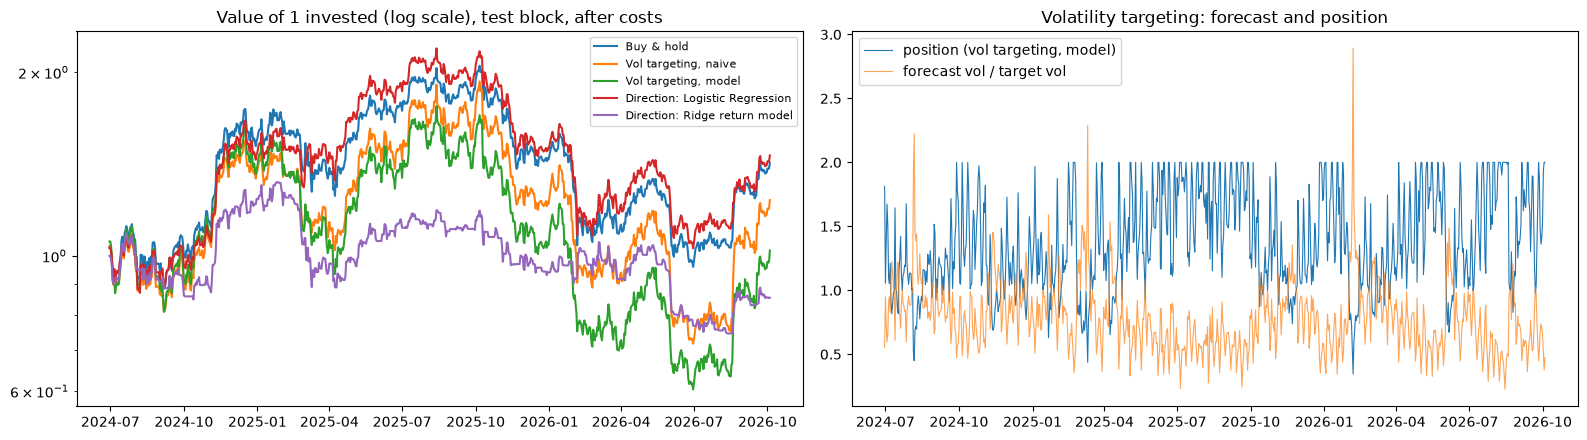

In [38]:
COST = 0.001
day_ret = U.compound(Y["test"][test_days]) / 100                      # realized next-day simple return
vol_model = np.exp(dv_together["ALL (selected)"])                     # forecast daily volatility, %
vol_naive = np.exp(dv_test_pred["Baseline: last week's average volatility"])
sigma_star = np.median(np.exp(yd_tv))
positions = {
    "Buy & hold": np.ones(len(day_ret)),
    "Vol targeting, naive": np.minimum(sigma_star / vol_naive, 2),
    "Vol targeting, model": np.minimum(sigma_star / vol_model, 2),
    f"Direction: {clf_name}": (proba_te > 0.5).astype(float),
    f"Direction: {reg_name} return model": (retA_te > 0).astype(float),
}

def backtest(pos, r=day_ret, cost=COST):
    turnover = np.abs(np.diff(np.r_[0, pos]))
    return pos * r - cost * turnover

def perf(sr, pos):
    eq = np.cumprod(1 + sr)
    dd = 1 - eq / np.maximum.accumulate(eq)
    return {"annual return": sr.mean() * 365, "annual vol": sr.std() * np.sqrt(365), "Sharpe": sr.mean() / sr.std() * np.sqrt(365),
            "max drawdown": dd.max(), "final value of 1": eq[-1], "avg position": pos.mean(),
            "turnover per day": np.abs(np.diff(pos)).mean(), "Sharpe before costs": (pos * day_ret).mean() / (pos * day_ret).std() * np.sqrt(365)}

strat = {k: backtest(p) for k, p in positions.items()}
perf_tab = pd.DataFrame({k: perf(strat[k], positions[k]) for k in positions}).T
display(perf_tab.round(3))
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
for k in positions:
    ax[0].plot(D["test"][test_days], np.cumprod(1 + strat[k]), label=k)
ax[0].set_yscale("log"); ax[0].set_title("Value of 1 invested (log scale), test block, after costs"); ax[0].legend(fontsize=8)
ax[1].plot(D["test"][test_days], positions["Vol targeting, model"], lw=0.8, label="position (vol targeting, model)")
ax[1].plot(D["test"][test_days], vol_model / sigma_star, lw=0.8, alpha=0.7, label="forecast vol / target vol")
ax[1].set_title("Volatility targeting: forecast and position"); ax[1].legend(); plt.tight_layout(); plt.show()

**What we see**

- **Direction models.** The classifier (Logistic Regression, C = 10⁻⁴) has test AUC 0.522, accuracy 50.8%. The return model (Ridge) has test R²_oos +0.004 and IC 0.058, the best *daily* return numbers of the project. As strategies:
  - The classifier's "long or flat" strategy ends slightly ahead of buy & hold (Sharpe 0.60 vs 0.57, same drawdown), but its AUC is not significantly above 0.5 (section 14), so this is not distinguishable from luck.
  - The return model's strategy **loses** (Sharpe −0.01): it is out of the market on many strong days and trades a lot (turnover 0.35/day). A positive IC on log returns does not automatically make money.
- **Volatility targeting does worse than buy & hold** (Sharpe 0.29 model, 0.44 naive, vs 0.57). Two reasons, both visible in the right plot:
  1. **The target was set on train + validation, which were more volatile than the test period.** The forecast volatility was usually below the target, so the strategy held **1.4× leverage on average** and often hit the cap of 2. It amplified the 2026 drawdowns (max drawdown 66% vs 53%).
  2. **Costs:** the model's forecast changes every day, so the position changes a lot (turnover 0.195/day ≈ 7% of capital per year in fees). Even *before* costs its Sharpe (0.42) is below buy & hold.

  In stock markets, volatility targeting is known to work largely because volatility rises when prices fall. In this Bitcoin test period that link was too weak for it to pay off.

**Conclusion of D3:** a good volatility forecast (R² ≈ 0.47) is **not** automatically a profitable strategy. The design choices (target level, leverage cap, how often to rebalance) matter as much as the forecast. They were *not* tuned here: tuning them on the test period would be cheating. Section 16 explains how to tune them correctly.

## 14. D1, D2, D4 — How sure are we? Confidence intervals, learning curves, regimes and calibration

### D1: block-bootstrap confidence intervals

Every test number so far is a single value from one 2.25-year period. The **moving-block bootstrap** estimates how much it could change with a different sample of days: the 827 test days are resampled in blocks of 10 consecutive days (blocks keep the volatility clustering intact) 1,000 times, and the statistic is recomputed each time. The 2.5% and 97.5% percentiles give a 95% confidence interval.

For a **difference** between two models (computed on the same resampled days), an interval that excludes 0 means the difference is reliable.

In [39]:
ND = len(test_days)
days_rows = lambda idx: (test_days[idx][:, None] * 24 + np.arange(24)).ravel()
abs_all = abs_together["ALL (selected)"]
ret_all = ret_together["ALL (selected)"]
dv_all, dv_ref = dv_together["ALL (selected)"], dv_together["Reference (version 2)"]
rule_te = abs_test_pred["Baseline: last week x hour profile"]
boot_stats = {
    "next-day vol R², ALL": lambda i: U.r2(yd_te[i], dv_all[i]),
    "next-day vol R², ALL − reference": lambda i: U.r2(yd_te[i], dv_all[i]) - U.r2(yd_te[i], dv_ref[i]),
    "hourly |r| R², ALL": lambda i: U.r2(ya_te[days_rows(i)], abs_all[days_rows(i)]),
    "hourly |r| R², ALL − rule": lambda i: U.r2(ya_te[days_rows(i)], abs_all[days_rows(i)]) - U.r2(ya_te[days_rows(i)], rule_te[days_rows(i)]),
    "hourly returns IC, ALL": lambda i: U.safe_corr(ret_all[days_rows(i)], yr_te[days_rows(i)]),
    "hourly returns R²_oos, ALL": lambda i: U.r2_oos(yr_te[days_rows(i)], ret_all[days_rows(i)]),
    f"direction AUC − 0.5, {clf_name}": lambda i: roc_auc_score(yb_te[i], proba_te[i]) - 0.5,
    "Sharpe, vol targeting (model) − buy & hold": lambda i: (strat["Vol targeting, model"][i].mean() / strat["Vol targeting, model"][i].std()
                                                             - strat["Buy & hold"][i].mean() / strat["Buy & hold"][i].std()) * np.sqrt(365),
    "Sharpe, vol targeting (model) − (naive)": lambda i: (strat["Vol targeting, model"][i].mean() / strat["Vol targeting, model"][i].std()
                                                          - strat["Vol targeting, naive"][i].mean() / strat["Vol targeting, naive"][i].std()) * np.sqrt(365),
}
boot_rows = {}
for name, fn in boot_stats.items():
    b = U.block_bootstrap(fn, ND, n_boot=1000, block=10, seed=RANDOM_STATE)
    boot_rows[name] = {"estimate": fn(np.arange(ND)), "CI 2.5%": np.percentile(b, 2.5), "CI 97.5%": np.percentile(b, 97.5),
                       "share of resamples > 0": (b > 0).mean()}
display(pd.DataFrame(boot_rows).T.round(4))

,estimate,CI 2.5%,CI 97.5%,share of resamples > 0
"next-day vol R², ALL",0.4647,0.3986,0.5189,1.000
"next-day vol R², ALL − reference",-0.0134,-0.0229,-0.0018,0.008
"hourly |r| R², ALL",0.1205,0.0989,0.1438,1.000
"hourly |r| R², ALL − rule",0.0680,0.0543,0.0818,1.000
"hourly returns IC, ALL",0.0120,-0.0082,0.0323,0.894
"hourly returns R²_oos, ALL",-0.0000,-0.0011,0.0011,0.507
"direction AUC − 0.5, Logistic Regression",0.0225,-0.0131,0.0623,0.909
"Sharpe, vol targeting (model) − buy & hold",-0.2785,-0.6380,0.0579,0.050
"Sharpe, vol targeting (model) − (naive)",-0.1458,-0.4219,0.1069,0.113


**What the intervals say**

| Result | 95% interval | Verdict |
|---|---|---|
| next-day volatility R² (ALL) | 0.40 – 0.52 | clearly predictable |
| next-day volatility: ALL − version 2 | −0.023 – −0.002 | ALL slightly but reliably *worse* on this test period (section 12.3) |
| hourly \|r\| R² (ALL) | 0.10 – 0.14 | clearly predictable |
| hourly \|r\|: ALL − best rule | **+0.054 – +0.082** | the model is reliably better than the rule |
| hourly returns IC (ALL) | −0.008 – +0.032 | includes 0: no reliable signal |
| hourly returns R²_oos (ALL) | −0.0011 – +0.0011 | centred on 0 |
| direction AUC − 0.5 | −0.013 – +0.062 | includes 0: not reliably better than a coin |
| Sharpe: vol targeting (model) − buy & hold | −0.64 – +0.06 | worse, at the edge of significance |
| Sharpe: vol targeting (model) − naive | −0.42 – +0.11 | no reliable difference |

The intervals separate the project's results into two groups. **Volatility (daily and hourly) is predictable with high confidence. Returns and direction are not distinguishable from zero.** That is the central result.

### D2: learning curves — does more training data help?

Each model is trained on the **most recent** 6, 12, 24, 36 months of the train block, or all of it (≈59 months), and scored on the validation block, with fixed hyperparameters. If a target has real, stable structure, the validation score should rise with more data; if it is noise, more data changes nothing.

,origins,next-day vol R²,hourly |r| R²,hourly returns R²_oos,hourly returns IC,next-day return IC
months of training,,,,,,
6,733,0.4342,0.0966,-0.0008,-0.0040,-0.0323
12,1461,0.4338,0.1018,-0.0017,0.0105,0.0247
24,2921,0.4154,0.0914,-0.0002,0.0218,0.0511
36,4385,0.4153,0.0911,0.0005,0.0221,0.0499
59,7149,0.4087,0.0886,0.0004,0.0221,0.0444


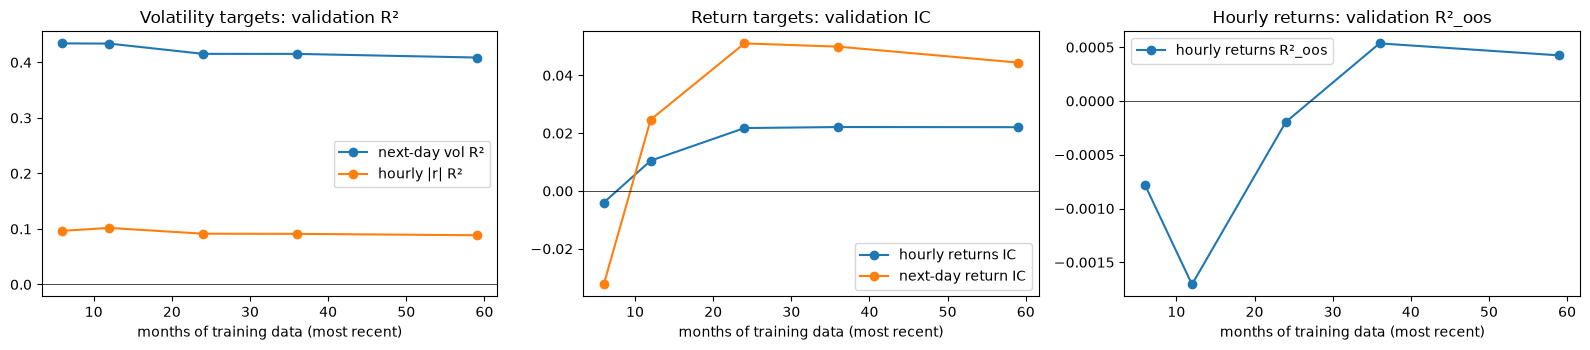

In [40]:
lc_rows = []
X_ret_tr, X_ret_va = Xl("train", BASE, H_BASE + B3), Xl("val", BASE, H_BASE + B3)
for months in [6, 12, 24, 36, None]:
    sel_o = np.arange(n_tr) if months is None else np.flatnonzero(D["train"] >= D["train"][-1] - pd.DateOffset(months=months))
    sel_r = rows24(sel_o)
    r = {"months of training": months or round((D["train"][-1] - D["train"][0]).days / 30.4), "origins": len(sel_o)}
    gbd = HistGradientBoostingRegressor(learning_rate=0.1, max_depth=2, min_samples_leaf=20, max_iter=100, early_stopping=False,
                                        random_state=RANDOM_STATE)
    r["next-day vol R²"] = U.r2(yd_va, gbd.fit(Xw("train", BASE)[sel_o], yd_tr[sel_o]).predict(Xw("val", BASE)))
    gba = HistGradientBoostingRegressor(early_stopping=False, max_iter=100, random_state=RANDOM_STATE, **p_abs_hgb)
    r["hourly |r| R²"] = U.r2(ya_va, gba.fit(XA_tr[sel_r], ya_tr[sel_r]).predict(XA_va))
    pr = make_ridge(alpha=100_000).fit(X_ret_tr[sel_r], yr_tr[sel_r]).predict(X_ret_va)
    r["hourly returns R²_oos"], r["hourly returns IC"] = U.r2_oos(yr_va, pr), U.safe_corr(pr, yr_va)
    pa = make_ridge(alpha=100_000).fit(Xw("train", BASE)[sel_o], yA_tr[sel_o]).predict(Xw("val", BASE))
    r["next-day return IC"] = U.safe_corr(pa, yA_va)
    lc_rows.append(r)
lc = pd.DataFrame(lc_rows).set_index("months of training")
display(lc.round(4))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
lc[["next-day vol R²"]].plot(ax=ax[0], marker="o", title="Volatility targets: validation R²")
lc[["hourly |r| R²"]].plot(ax=ax[0], marker="o", secondary_y=False)
lc[["hourly returns IC", "next-day return IC"]].plot(ax=ax[1], marker="o", title="Return targets: validation IC")
lc[["hourly returns R²_oos"]].plot(ax=ax[2], marker="o", title="Hourly returns: validation R²_oos")
for a in ax:
    a.axhline(0, c="k", lw=0.5); a.set_xlabel("months of training data (most recent)")
plt.tight_layout(); plt.show()

**What we see**

- **Volatility targets get *worse* with more history:** next-day volatility R² falls from 0.434 (last 6 months only) to 0.409 (all 59 months), and hourly |r| peaks at 12 months (0.102). The relationship between today's features and tomorrow's volatility **drifts** over time: recent data describes the validation period better than 2018 data does. (Version 2 found the same for the very old years.)
- **Return targets need a lot of history:** the hourly return IC rises from −0.004 (6 months) to ≈0.022 (from 24 months on), and the next-day return IC from −0.03 to ≈0.05. The tiny return signal can only be estimated from many examples, and adding more data never makes it large.
- This suggests two different training strategies: **recent windows (or recency weights) for volatility**, the **full history for returns** (section 16).

### D4: regimes and calibration

**Regimes.** The test days are split by two conditions that are *known at the forecast origin* (so the split itself uses no future information):
- **volatility regime**: tercile of last week's volatility (calm / middle / wild);
- **trend regime**: whether the price rose or fell over the last 30 days (bull / bear).

For each regime: the next-day volatility model (ALL) against the naive rule, the hourly |r| model, the IC of the hourly return model and the accuracy of the direction classifier.

In [41]:
vol_reg = pd.qcut(vol_naive, 3, labels=["calm", "middle", "wild"])
trend_reg = np.where(FEAT["ret_30d"].values[P["test"][test_days]] > 0, "bull (30d up)", "bear (30d down)")
reg_rows = []
for kind, labels in [("volatility", vol_reg), ("trend", trend_reg)]:
    for lab in pd.unique(labels):
        i = np.flatnonzero(np.asarray(labels) == lab)
        reg_rows.append({"regime": f"{kind}: {lab}", "days": len(i),
                         "next-day vol R² (ALL)": U.r2(yd_te[i], dv_all[i]),
                         "next-day vol R² (naive)": U.r2(yd_te[i], np.log(vol_naive[i])),
                         "next-day vol MAE (ALL)": mean_absolute_error(yd_te[i], dv_all[i]),
                         "hourly |r| R² (ALL)": U.r2(ya_te[days_rows(i)], abs_all[days_rows(i)]),
                         "hourly returns IC (ALL)": U.safe_corr(ret_all[days_rows(i)], yr_te[days_rows(i)]),
                         "direction accuracy": accuracy_score(yb_te[i], proba_te[i] > 0.5),
                         "up-day share": yb_te[i].mean()})
display(pd.DataFrame(reg_rows).set_index("regime").round(3))

,days,next-day vol R² (ALL),next-day vol R² (naive),next-day vol MAE (ALL),hourly |r| R² (ALL),hourly returns IC (ALL),direction accuracy,up-day share
regime,,,,,,,,
volatility: middle,275,0.376,-0.024,0.303,0.086,-0.003,0.469,0.480
volatility: calm,276,0.360,-0.012,0.300,0.081,-0.018,0.496,0.496
volatility: wild,276,0.335,-0.207,0.298,0.093,0.027,0.558,0.536
trend: bear (30d down),378,0.465,0.134,0.314,0.123,0.008,0.516,0.513
trend: bull (30d up),449,0.428,0.002,0.289,0.100,0.017,0.501,0.497


**What we see**

- **The volatility model works in every regime.** Within each volatility tercile it still explains 34–38% of the day-to-day variation, while the naive rule is *negative* within each tercile (it only knows the level, not the day-to-day changes). It does a bit better in bear trends (0.47) than in bull trends (0.43).
- **The hourly |r| model** also works in all regimes (R² 0.08–0.12).
- **Hourly return IC** is ≈ 0 in every regime (−0.02 to +0.03): there is no hidden regime where returns become predictable.
- **Direction accuracy** is 55.8% in the wild tercile, but 53.6% of those days were up days. Most of it is the base rate, not skill.

**Calibration of the direction classifier.** When the classifier says "60% chance of an up day", are 60% of those days really up? The days are grouped into 5 bins by predicted probability, and the actual share of up days in each bin is plotted against the average prediction. A perfectly calibrated model lies on the diagonal. The **Brier score** (mean squared error of the probabilities) is compared with always predicting the training up-share.

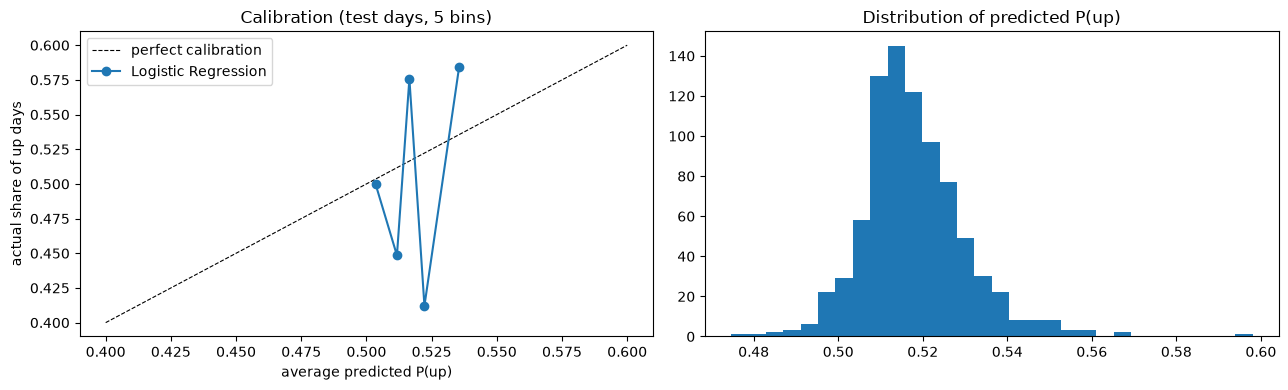

Brier score: model 0.2498  vs. always the training up-share 0.2502  (predicted P(up) ranges 0.475 – 0.598)
Total run time: 43.6 minutes


In [42]:
frac_up, mean_pred = calibration_curve(yb_te, proba_te, n_bins=5, strategy="quantile")
brier = np.mean((proba_te - yb_te) ** 2)
brier0 = np.mean((yb_tv.mean() - yb_te) ** 2)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot([0.4, 0.6], [0.4, 0.6], "k--", lw=0.8, label="perfect calibration")
ax[0].plot(mean_pred, frac_up, "o-", label=clf_name)
ax[0].set_xlabel("average predicted P(up)"); ax[0].set_ylabel("actual share of up days"); ax[0].legend()
ax[0].set_title("Calibration (test days, 5 bins)")
ax[1].hist(proba_te, bins=30); ax[1].set_title("Distribution of predicted P(up)")
plt.tight_layout(); plt.show()
print(f"Brier score: model {brier:.4f}  vs. always the training up-share {brier0:.4f}  "
      f"(predicted P(up) ranges {proba_te.min():.3f} – {proba_te.max():.3f})")
print(f"Total run time: {(time.time() - T_START) / 60:.1f} minutes")

**What we see.** The classifier's probabilities stay between 0.475 and 0.598, and almost all lie in 0.50–0.53: it never makes a confident call. The calibration curve zig-zags around the diagonal, with no clear relation between predicted and actual up-share. The Brier score (0.2498) is only 0.0004 better than always predicting the training up-share (0.2502). The classifier **"knows that it doesn't know"**: its probabilities are honest, but they carry almost no information. This is the classification version of the "predict ≈ 0" behaviour of the return regressors.

## 15. Conclusions

These results come from the run on the data available on 5 October 2026 (train Feb 2018 → Dec 2022, validation Jan 2023 → Jun 2024, test Jul 2024 → Oct 2026, 827 independent test days).

### 1. Why the hourly forecasts looked like pure noise

Because the **direction** of hourly Bitcoin moves *is* almost pure noise (section 4). The only dependence in hourly returns is a tiny reversal at lags 1, 2 and 24 hours: statistically real, but able to explain at most ≈0.4% of the variance, and not stable from one period to the next. Two things made it look even worse in versions 1–2:
- **The metric mismatch** (section 7): models trained for the mean but judged by MAE, which rewards predicting 0, so the small signal that existed was thrown away.
- **The target ignored the predictable part**: the *size* of hourly moves is strongly autocorrelated (0.27 at lag 1, still 0.10 after a week) and follows the clock (1.5× between the busiest and quietest hour; weekends 0.8×).

### 2. How it was solved: ask the questions the data can answer

| 24-hour task, reformulated | Best result on test | vs. simple rule | Reliable? (95% CI) |
|---|---|---|---|
| **Size of each of the 24 next hours** (A2 + A6) | R² **0.115–0.123** | rule 0.053 | yes: model − rule = +0.054 to +0.082 |
| **80% range for each of the 24 next hours** (A3) | 36% narrower than fixed ranges, coverage 76–78% in calm *and* wild periods | fixed range: 95% / 83% | yes: lower pinball loss than both baselines for q10 and q90 |
| **Direction/size of each hour** (A4 + all) | IC 0.010–0.020, R²_oos ≈ 0 | zero forecast | no: IC interval includes 0, DM p ≥ 0.13 |

The assigned 24-hour structure is kept, but the forecast becomes "how much will each hour move, and within which range", which is useful (risk, position sizing, execution timing), where the old forecast "≈ 0% every hour" was not.

### 3. What each improvement did (separately and inside the full combination)

| Improvement | Effect |
|---|---|
| **A1** analysis | explains the whole problem; the most important "improvement" for the report |
| **A6** long format | **largest single gain**: hourly volatility R² +43% on validation; leave-one-out confirms it is the key ingredient for both hourly targets |
| **A2 / A3** new hourly targets | turn the 24-hour task into one with clear, significant skill |
| **A4** matching metric | return IC 0.005 → 0.020 and R²_oos turns positive; not significant |
| **B1 / B2** 30-day and range-based volatility | no gain (the base features already contain the information) |
| **B3** per-hour features | almost doubles the walk-forward return IC (0.013 → 0.024); neutral for volatility |
| **B4** permutation importance | shows which inputs matter; unreliable for correlated features |
| **C1** walk-forward CV | fixes the bad next-day-return choice of version 2 and shows the true uncertainty (±0.04 R² between periods) |
| **C2** tuned number of trees | small, consistent gain; random early stopping used up to 4–5× too many trees |
| **A5 / C3** scaled target, weights, Huber | helps linear return models on validation only; nothing robust on test |
| **C4** more models | trees > SVR > linear > KNN for volatility; ElasticNet keeps 5 return features |
| **C5** ensembles | +7% for hourly volatility (walk-forward); no gain for next-day volatility |
| **C6** random search | same result as the full grid at 1/3 of the cost |
| **All together** | hourly \|r\|: 0.080 → 0.115 (+44%). Hourly returns: better on validation, still ≈0 on test. Next-day volatility: 0.478 → 0.465, slightly *worse*, within selection noise |

### 4. The broader lessons

- **More tuning does not beat noise.** For returns, every improvement helped on validation and none survived to the test block in a significant way. For next-day volatility, the "improved" pipeline was slightly worse on test. When the differences between candidates are smaller than the fold-to-fold spread, model selection itself is partly random. Confidence intervals (section 14) are the only honest way to report such results.
- **A good forecast is not automatically a good strategy** (section 13). Volatility targeting with an R² ≈ 0.47 forecast still lost to buy & hold, because of its design (target level, leverage, trading costs), not because of the forecast.
- **Volatility relationships drift; return signals are tiny** (section 14). Volatility models do better with recent data, return models need all the history they can get.
- **No hidden regime** makes returns predictable (section 14).

### 5. Limitations

- **One test period** (2.25 years). A different period could rank the close variants differently, as the bootstrap intervals show.
- **Many tests on the return target** (≈40 in this notebook). The few p-values below 0.05 for confident forecasts (e.g. 0.001 in section 10) are what multiple testing produces by chance; none was the validation choice.
- **A few best hyperparameters still lie on a grid edge** (quantile models, Gradient Boosting depth 2 for hourly |r|, Extra Trees depth 24, ElasticNet l1_ratio 0.01, Ridge alphas). In every case the neighbouring value scores within the selection noise (a plateau). The notebook already takes 45 minutes, so they were not extended again.
- The economic test ignores slippage, funding costs of leverage and taxes.

**Recommended story for the project:** "Hourly Bitcoin returns are close to a random walk: their direction carries less than 1% predictable variance, and no amount of model tuning makes it reliably predictable. Asking the questions the data *can* answer changes everything: one scikit-learn model in long format predicts the size of each of the next 24 hours 2.2× better than a volatility rule, and quantile models give 80% ranges that are 36% narrower than fixed ones and adapt to calm and wild markets. Walk-forward validation, bootstrap intervals and an economic test keep the conclusions honest: volatility is predictable, direction is not, and a good forecast still needs a good decision rule to be useful."

## 16. Ideas and suggestions

**For the models (could be done in this notebook):**

1. **Calibrated ranges (conformal prediction).** The 80% intervals cover 77%. Split-conformal calibration widens them by the error quantile observed on the validation block, which guarantees ≈80% coverage on new data. It needs only a few lines of NumPy on top of the quantile models.
2. **Recency for volatility.** The learning curves show volatility models do better on recent data. Two options: a rolling training window (e.g. last 12 months, refitted every month), or `sample_weight` that decays with age. Both are tuned with walk-forward CV.
3. **Refit as the test progresses.** All models were fitted once, in mid-2024, and used for 2.25 years. Refitting every month on all data available at that time (still never using the future) is how such a model would be used in practice, and should help the drifting volatility relationships.
4. **More robust selection.** When candidates are within the fold-to-fold noise, average the top-k settings instead of picking the single best, or prefer the simplest setting within one standard deviation of the best (the "one-standard-error rule").
5. **Tune the strategy, not only the forecast, on validation:** target volatility, leverage cap and a "no-trade band" (only change the position when it moves by more than e.g. 20%, which cuts turnover and costs). Then test once.
6. **Intraday use of the hourly volatility forecast:** e.g. scheduling large orders in the quietest predicted hours, a direct application of the A2 model.
7. **LightGBM or XGBoost** through their scikit-learn interfaces, if the course allows them: same ideas as HistGradientBoosting, more options (e.g. a Huber loss for trees).

**For the data preparation (suggestions only, not implemented):**

1. **Publish the continuous hourly series** (as rebuilt in section 1) next to the windows. It is 168× smaller and lets any model choose its own lookback.
2. **Other markets as inputs**: ETH, S&P 500 / Nasdaq futures, the US dollar index. Bitcoin volatility often reacts to them.
3. **Crypto-specific data**: funding rates and open interest of perpetual futures, exchange order-book depth. These are the inputs most often reported to carry short-term information.
4. **A "no trade" flag** for forward-filled hours, as suggested in version 2.